In [102]:
import os, sys, pickle, hashlib, json as _json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from collections import Counter
from scipy import stats as _stats
from IPython import get_ipython

sys.path.insert(0, '/Users/yotameviatar/startle-1')

from Airflow import airflow_config as config
from Airflow import airflow_glm as glm
from Airflow import airflow_qc

get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams.update({'figure.dpi': 110})
print('Setup complete —', matplotlib.get_backend())


Setup complete — inline


## Setup — cache & scoring (run once)

In [103]:
SUBJECT = 'MS18'
METRIC  = 'RA'
FORCE_RESCORE = globals().get('FORCE_RESCORE', False)

cache_path = os.path.join(config.OUTPUT_DIR, "_cache", "airflow_cache.pkl")
with open(cache_path, "rb") as f:
    sessions_cache = pickle.load(f)["sessions"]

def _config_fingerprint():
    items = {}
    for k in dir(config):
        if k.startswith("_"):
            continue
        v = getattr(config, k)
        if callable(v):
            continue
        try:
            _json.dumps(v)
            items[k] = v
        except TypeError:
            pass
    items["__cache_mtime"] = os.path.getmtime(cache_path)
    blob = _json.dumps(items, sort_keys=True, default=str)
    return hashlib.md5(blob.encode()).hexdigest()[:12]

_score_cache = os.path.join(config.OUTPUT_DIR, "_cache",
                            f"glm_scoring_{_config_fingerprint()}.pkl")

if os.path.exists(_score_cache) and not FORCE_RESCORE:
    with open(_score_cache, "rb") as f:
        _sc = pickle.load(f)
    trials_data, traces = _sc["trials_data"], _sc["traces"]
    print(f"Loaded cached scoring: {os.path.basename(_score_cache)}")
else:
    print("Scoring all sessions (first time only, then cached) ...")
    trials_data, traces = glm.run_glm_scoring(sessions_cache, config)
    with open(_score_cache, "wb") as f:
        pickle.dump({"trials_data": trials_data, "traces": traces}, f)
    print(f"Scored and cached: {os.path.basename(_score_cache)}")

if SUBJECT not in sessions_cache:
    raise ValueError(f"Subject '{SUBJECT}' not found. Available: {sorted(sessions_cache.keys())}")

sess_keys = sorted(sessions_cache[SUBJECT].keys())
print(f"{len(trials_data)} subjects scored · {SUBJECT} sessions: {sess_keys}")


Loaded cached scoring: glm_scoring_10a9293d1074.pkl
21 subjects scored · MS18 sessions: ['eve', 'mor']


## QC pipeline — raw signal → GLM input (session-wide, one subject)

In [104]:
def compute_session_qc(subj, sess_key):
    sess = sessions_cache[subj][sess_key]
    signal_raw = sess["signal_raw"]
    native_sfreq = float(sess["sfreq"])
    trials_meta = sess["trials_meta"]

    breath_size = airflow_qc.session_breath_size(
        signal_raw, native_sfreq, band=getattr(config, "QC_BREATH_BAND", (0.01, 0.6)))

    raw_z, sfreq = glm.phase1_filter_downsample(
        signal_raw, native_sfreq, target_sfreq=config.GLM_TARGET_SFREQ,
        bp_low=config.GLM_CYCLE_BANDPASS[0], bp_high=config.GLM_CYCLE_BANDPASS[1],
        zscore=config.GLM_ZSCORE_RAW, despike=False)

    cycles = glm.detect_cycles(
        raw_z, sfreq, signal_raw, native_sfreq,
        median_win_sec=config.GLM_MEDIAN_WIN_SEC, refractory_sec=config.GLM_REFRACTORY_SEC)

    peak_times, _ = glm._nk2_peak_trough_times(raw_z, sfreq, config)
    glm.attach_cycle_features(cycles, signal_raw, native_sfreq, peak_times)

    rejected, reason, rep = airflow_qc.classify_cycles(cycles, config)
    rejected, reason = airflow_qc.apply_neighbour_rules(rejected, reason, config)
    report = airflow_qc._cycle_report(cycles, rejected, reason, rep["abstained"],
                                      rep["n_ref_cycles"], rep["median_RA"], rep["cut_RA"])

    manual_spans = [(float(a), float(b)) for a, b in
                    getattr(config, "MANUAL_BAD_SPANS", {}).get(f"{subj}/{sess_key}", [])]
    if manual_spans:
        keep = [not any(c["onset_time"] < b and c["assign_time"] > a for a, b in manual_spans)
                for c in cycles]
        cycles   = [c for c, k in zip(cycles, keep) if k]
        rejected = np.array([r for r, k in zip(rejected, keep) if k], dtype=bool)
        reason   = [r for r, k in zip(reason, keep) if k]
    missing_spans = list(manual_spans)

    n_samples = len(raw_z)
    d105_times = [m["d105_time"] for m in trials_meta if m.get("d105_time") is not None]
    code_times = [m["code_time"] for m in trials_meta if m.get("code_time") is not None]
    win_start = win_end = None
    if d105_times and code_times:
        win_start = min(d105_times) - config.GLM_PRE_FIXATION_SEC
        win_end   = max(code_times) + config.GLM_POST_CODE_SEC
        n_samples = min(n_samples, int(np.ceil(max(win_end, 0.0) * sfreq)))
        if win_start > 0:
            missing_spans = missing_spans + [(0.0, win_start)]

    rej_spans = glm.rejected_cycle_spans(cycles, rejected) if len(cycles) else []

    series, times_full = glm.build_continuous_series(
        cycles, n_samples, sfreq, hp=config.GLM_FINAL_HP, lp=config.GLM_FINAL_LP,
        missing_spans=missing_spans, rejected=rejected)

    return dict(
        signal_raw=signal_raw, signal_clean=signal_raw, native_sfreq=native_sfreq,
        raw_z=raw_z, sfreq=sfreq, cycles=cycles, series=series, times_full=times_full,
        rejected=rejected, reason=reason, report=report, rej_spans=rej_spans,
        breath_size=breath_size, masked_spans=[], masked_sec=0.0, deep_spans=rej_spans,
        win_start=win_start, win_end=win_end)


### Single-condition GLM score — Evening vs Morning (no differentiation: sound/no-sound and Negative/Neutral pooled into one condition)

Refits the pooled-session GLM per subject/session with every accepted trial forced into a single condition (`condition=1` for all), so the design matrix has exactly one CRF[+dCRF] regressor block and one β per session — a true single scalar per session, not a trial-count-weighted mix of condition-specific betas.

In [105]:
import pandas as pd

def compute_single_condition_scores(metric):
    cache_path = os.path.join(config.OUTPUT_DIR, "_cache",
                              f"glm_single_scoring_{metric}_{_config_fingerprint()}.pkl")
    if os.path.exists(cache_path) and not FORCE_RESCORE:
        with open(cache_path, "rb") as f:
            print(f"Loaded cached single-condition scores: {os.path.basename(cache_path)}")
            return pickle.load(f)

    print("Refitting pooled-session GLM with a single condition (no sound/label split, first time only, then cached) ...")
    scores = {}
    key = f"score_{metric.lower()}"
    for subj, sess_dict in trials_data.items():
        scores[subj] = {}
        for sess_key, trials in sess_dict.items():
            if not trials:
                continue
            S = compute_session_qc(subj, sess_key)
            trials_copy = [dict(t, condition=1) for t in trials]
            glm.fit_pooled_session_glm(trials_copy, S["series"], S["sfreq"], config)

            vals = [t[key] for t in trials_copy
                    if not t["rejected"] and t.get(key) is not None and np.isfinite(t[key])]
            scores[subj][sess_key] = float(np.mean(vals)) if vals else np.nan

    with open(cache_path, "wb") as f:
        pickle.dump(scores, f)
    print(f"Scored and cached: {os.path.basename(cache_path)}")
    return scores

single_scores = compute_single_condition_scores(METRIC)

Loaded cached single-condition scores: glm_single_scoring_RA_10a9293d1074.pkl


In [106]:
def _pct_diff(eve, mor):
    if not np.isfinite(mor) or mor == 0:
        return np.nan
    return (eve - mor) / abs(mor) * 100

rows = []
for subj in sorted(single_scores):
    b_eve = single_scores[subj].get("eve", np.nan)
    b_mor = single_scores[subj].get("mor", np.nan)
    rows.append({
        "Subject": subj,
        "B_eve": b_eve,
        "B_mor": b_mor,
        "Diff (%)": _pct_diff(b_eve, b_mor),
    })

single_cond_table = pd.DataFrame(rows).set_index("Subject").round(4)
single_cond_table

,B_eve,B_mor,Diff (%)
Subject,,,
AB22,-0.0004,-0.0003,-32.0715
AG05,-0.0001,-0.0001,-17.9769
AH19,0.0001,0.0002,-56.6073
AK12,-0.0002,-0.0003,43.0569
AS09,-0.0001,-0.0001,4.3600
EE10,-0.0002,-0.0002,9.9221
ER23,-0.0012,-0.0009,-33.0334
ES29,NaN,-0.0006,NaN
EV15,-0.0001,-0.0000,-571.8446


## main view

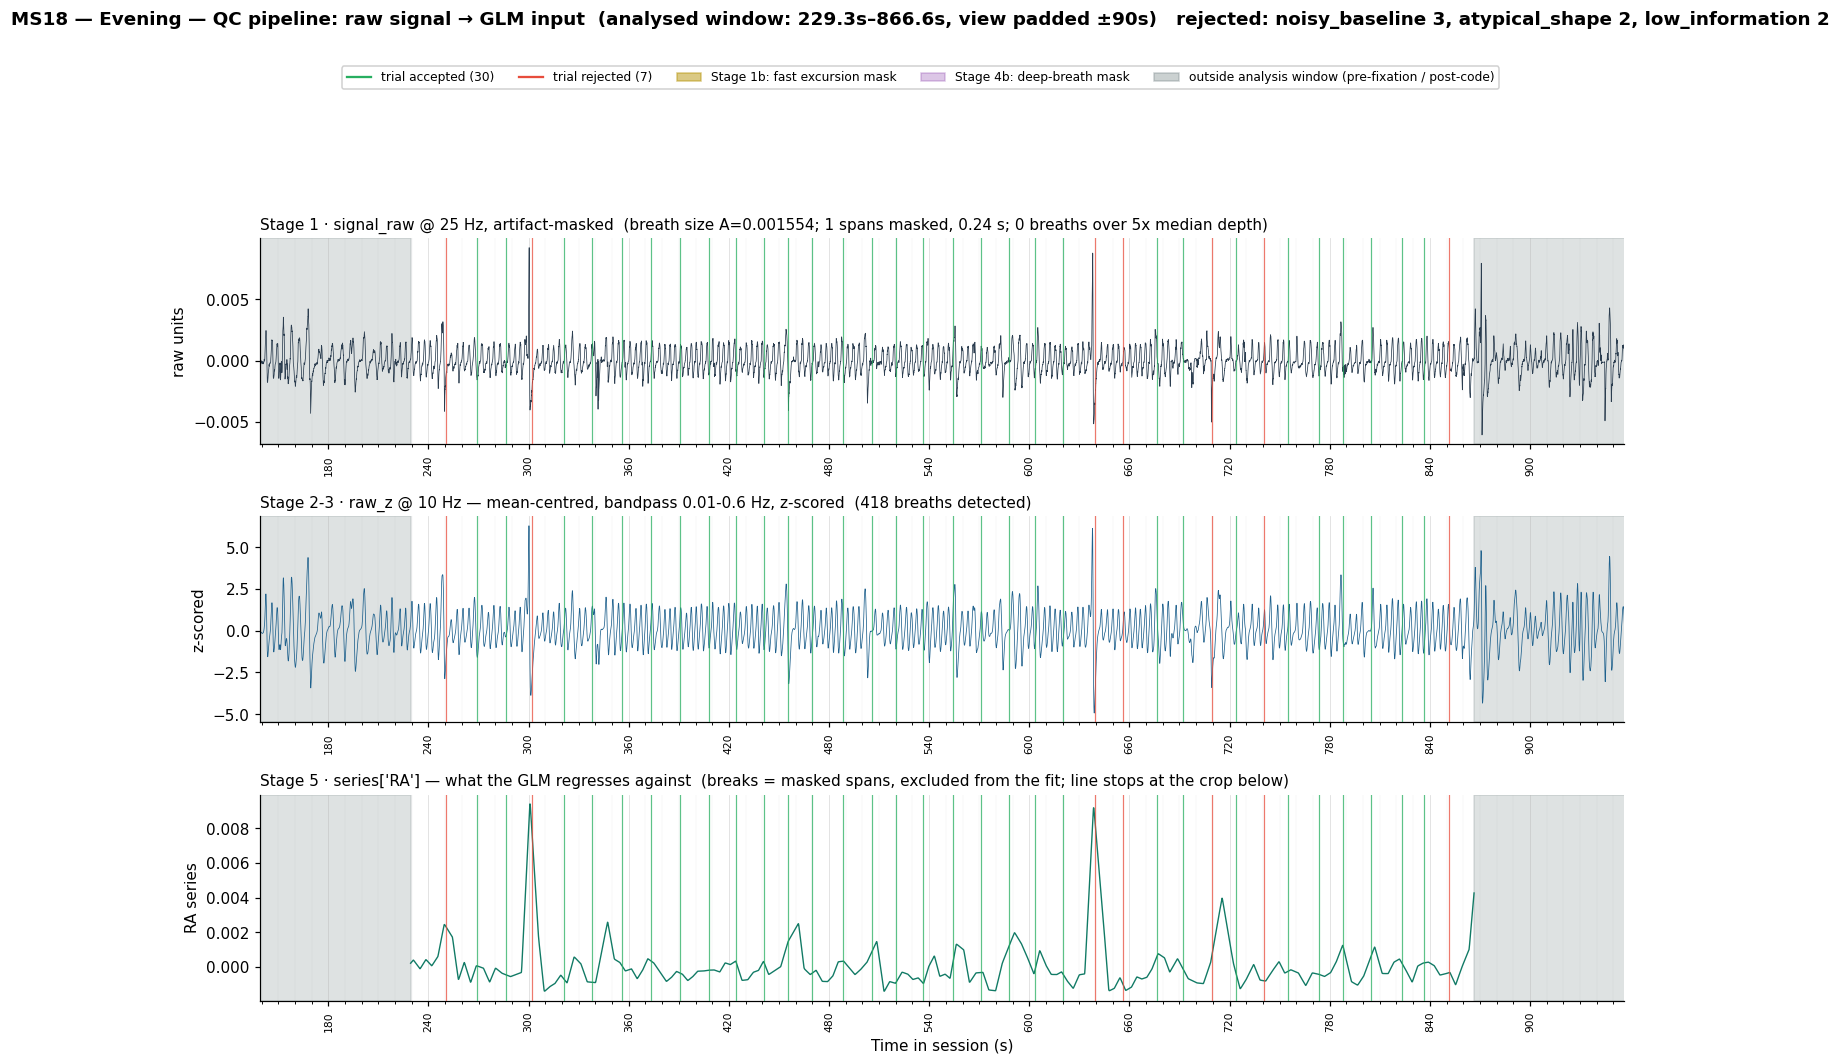

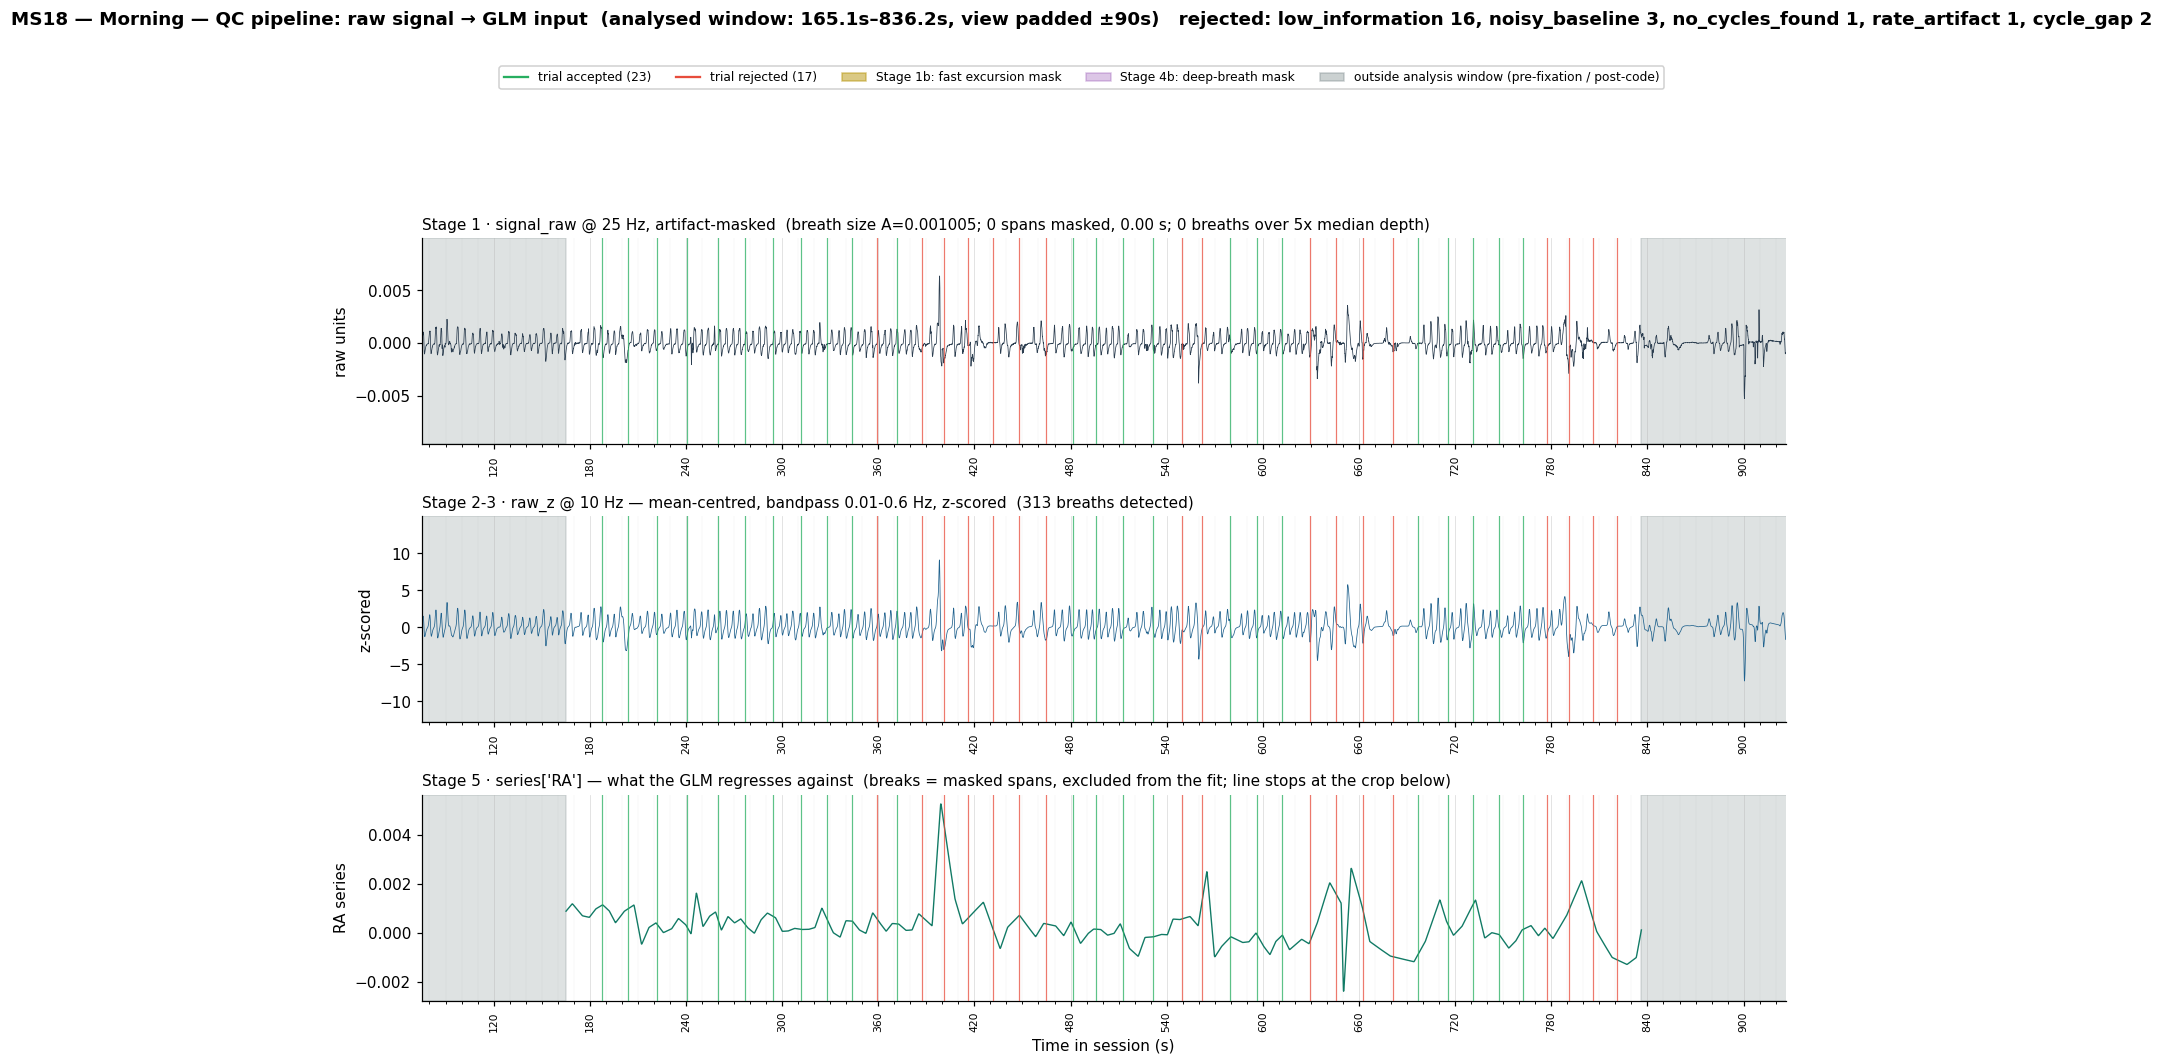

In [107]:
# Display-only zoom padding around the analysed window (win_start/win_end below
# are the REAL analysis crop, computed in compute_session_qc -- unaffected by this;
# this constant only controls how much of the excluded tail is still shown on-screen).
PLOT_MARGIN_SEC = 90.0

for sess_key in sess_keys:
    S = compute_session_qc(SUBJECT, sess_key)
    trials = trials_data.get(SUBJECT, {}).get(sess_key, [])
    sess_label = config.SESSION_MAP.get(sess_key, {}).get("label", sess_key)

    t_native = np.arange(len(S["signal_clean"])) / S["native_sfreq"]
    t_z      = np.arange(len(S["raw_z"])) / S["sfreq"]
    t_series = S["times_full"]
    session_end = t_native[-1] if len(t_native) else 0.0
    win_start = S["win_start"] if S["win_start"] is not None else 0.0
    win_end   = S["win_end"] if S["win_end"] is not None else session_end

    fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(16, 9), sharex=True,
                                        gridspec_kw=dict(hspace=0.35))

    ax0.plot(t_native, S["signal_clean"], color="#2C3E50", lw=0.5)
    for i0, i1 in S["rej_spans"]:
        ax0.axvspan(i0, i1, color="#A81D3C", alpha=0.18)

    for t in trials:
        col = "#27AE60" if not t.get("rejected") else "#E74C3C"
        for ax in (ax0, ax1, ax2):
            ax.axvline(t["onset_time"], color=col, lw=0.8, alpha=0.75, zorder=4)

    n_acc = sum(1 for t in trials if not t.get("rejected"))
    n_rej = sum(1 for t in trials if t.get("rejected"))
    reasons = Counter(r.strip() for t in trials if t.get("rejected")
                       for r in t.get("rejection_reason", "").split(",") if r.strip())
    reasons_str = ", ".join(f"{k} {v}" for k, v in reasons.items())

    _rep = S["report"]
    _gates = ", ".join(f"{g} {n}" for g, n in sorted(_rep["gate_counts"].items())) or "none"
    _abst = f" | ABSTAINED: {', '.join(_rep['abstained'])}" if _rep["abstained"] else ""
    ax0.set_title(
        f"Stage 1 · signal_raw @ {S['native_sfreq']:.0f} Hz — one verdict per breath  "
        f"(A={S['breath_size']:.6f}; "
        f"{len(S['cycles']) - int(np.sum(S['rejected']))}/{len(S['cycles'])} breaths kept = "
        f"{_rep['kept_seconds_frac']:.1%} of breath time; shaded = rejected)\n"
        f"gates: {_gates}{_abst}",
        fontsize=9, loc="left")
    ax0.set_ylabel("raw units")

    ax1.plot(t_z, S["raw_z"], color="#1F618D", lw=0.5)
    ax1.set_title(
        f"Stage 2-3 · raw_z @ {S['sfreq']:.0f} Hz — mean-centred, bandpass "
        f"{config.GLM_CYCLE_BANDPASS[0]}-{config.GLM_CYCLE_BANDPASS[1]} Hz, z-scored  "
        f"({len(S['cycles'])} breaths detected)", fontsize=10, loc="left")
    ax1.set_ylabel("z-scored")

    ax2.plot(t_series, S["series"][METRIC], color="#117A65", lw=0.9)
    ax2.set_title(
        f"Stage 5 · series['{METRIC}'] — what the GLM regresses against  "
        f"(breaks = masked spans, excluded from the fit; line stops at the crop below)",
        fontsize=10, loc="left")
    ax2.set_ylabel(f"{METRIC} series")
    ax2.set_xlabel("Time in session (s)")

    # Grey out everything outside the actual analysis window instead of hiding
    # it, so it's visible that it was recorded but excluded: GLM_PRE_FIXATION_SEC
    # before the first fixation and anything past GLM_POST_CODE_SEC after the
    # last trial's own code_time (mirrors run_glm_scoring's crop exactly,
    # airflow_glm.py Stage 6).
    for ax in (ax0, ax1, ax2):
        if win_start > 0:
            ax.axvspan(0.0, win_start, color="#7F8C8D", alpha=0.25, zorder=0)
        if win_end < session_end:
            ax.axvspan(win_end, session_end, color="#7F8C8D", alpha=0.25, zorder=0)
        ax.spines[["top", "right"]].set_visible(False)

    # Zoom to the analysed window + a short display-only tail on each side
    # (PLOT_MARGIN_SEC) -- otherwise idle pre/post-task time dominates the
    # x-axis and the actually-scored stretch gets squeezed unreadable.
    xlim_lo = max(win_start - PLOT_MARGIN_SEC, 0.0)
    xlim_hi = min(win_end + PLOT_MARGIN_SEC, session_end)
    for ax in (ax0, ax1, ax2):
        ax.set_xlim(xlim_lo, xlim_hi)
        ax.xaxis.set_major_locator(MultipleLocator(60))
        ax.xaxis.set_minor_locator(MultipleLocator(10))
        ax.grid(axis="x", which="major", lw=0.5, alpha=0.45, zorder=0)
        ax.grid(axis="x", which="minor", lw=0.3, alpha=0.20, zorder=0)
        ax.tick_params(axis="x", which="both", labelbottom=True,
                       labelsize=7, rotation=90)

    legend_handles = [
        plt.Line2D([0], [0], color="#27AE60", lw=1.5, label=f"trial accepted ({n_acc})"),
        plt.Line2D([0], [0], color="#E74C3C", lw=1.5, label=f"trial rejected ({n_rej})"),
        mpatches.Patch(color="#B7950B", alpha=0.5, label="Stage 1b: fast excursion mask"),
        mpatches.Patch(color="#8E44AD", alpha=0.3, label="Stage 4b: deep-breath mask"),
        mpatches.Patch(color="#7F8C8D", alpha=0.4, label="outside analysis window (pre-fixation / post-code)"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=5, fontsize=8,
               framealpha=0.9, bbox_to_anchor=(0.5, 1.06))
    fig.suptitle(
        f"{SUBJECT} — {sess_label} — QC pipeline: raw signal → GLM input  "
        f"(analysed window: {win_start:.1f}s\u2013{win_end:.1f}s, view padded \u00b1{PLOT_MARGIN_SEC:g}s)"
        f"{('   rejected: ' + reasons_str) if reasons_str else ''}",
        fontsize=12, fontweight="bold", y=1.11)

    plt.show()
    plt.close(fig)


## Cycle labeling — CSV + tagging view

Writes one CSV per session (`cycle_id, start_time, end_time, bad_start, bad_finish, decision`)
listing every detected breath cycle **inside the analysis window only** (`win_start`→`win_end`,
i.e. `GLM_PRE_FIXATION_SEC` before the first fixation trigger through `GLM_POST_CODE_SEC` after
the last picture code) — the same crop `run_glm_scoring` applies.

Fill in `decision` per row: `spike` · `flat` · `bad_cycle` · `merged` · `unsure`.
Blank `decision` = good cycle. Leave `bad_start`/`bad_finish` blank unless the problem is a
sub-part of the cycle. The y axis is in **robust z units** of `signal_clean` (median/MAD over the analysis
window). Every row shares the same scale (blue band) so normal breathing is comparable;
a row holding something bigger rescales to fit it and gets an **orange frame**, with that
row's peak |z| printed on the y label. Nothing is clipped.


MS18/eve: 167 cycles in 229.3-866.6s  ->  /Users/yotameviatar/Desktop/untitled folder/airflow_output/labeling/MS18_eve_labels.csv


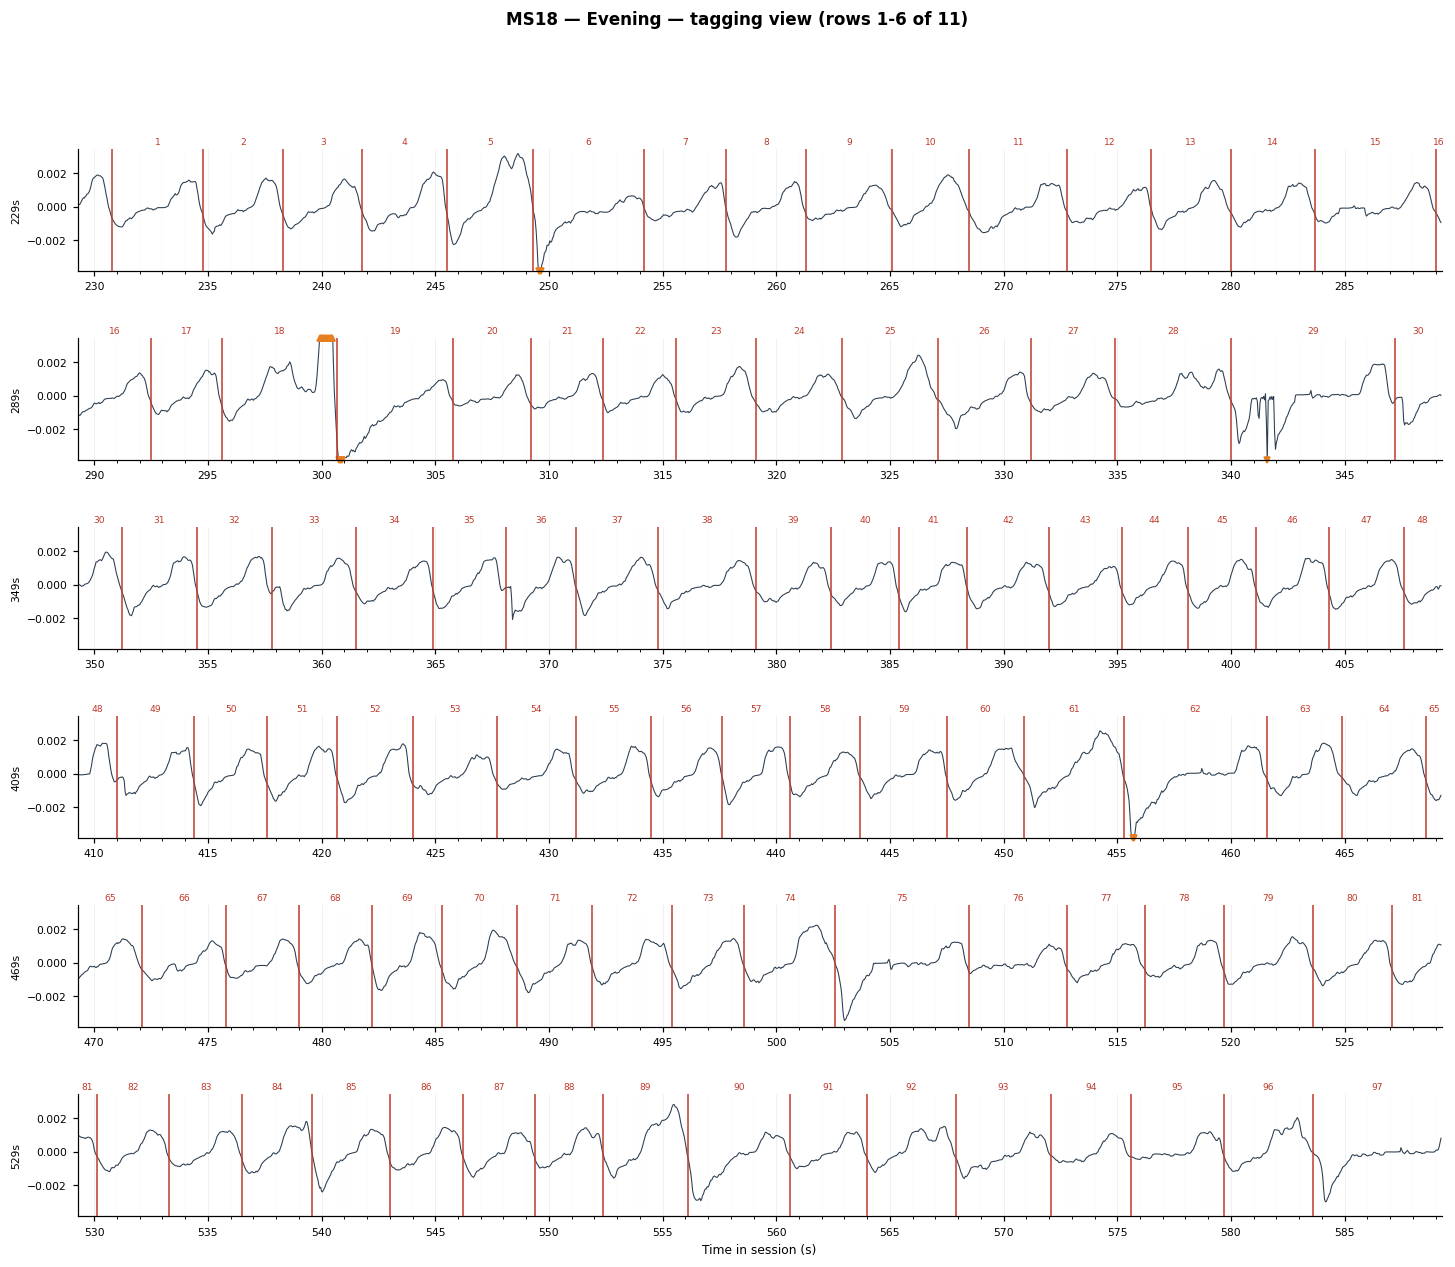

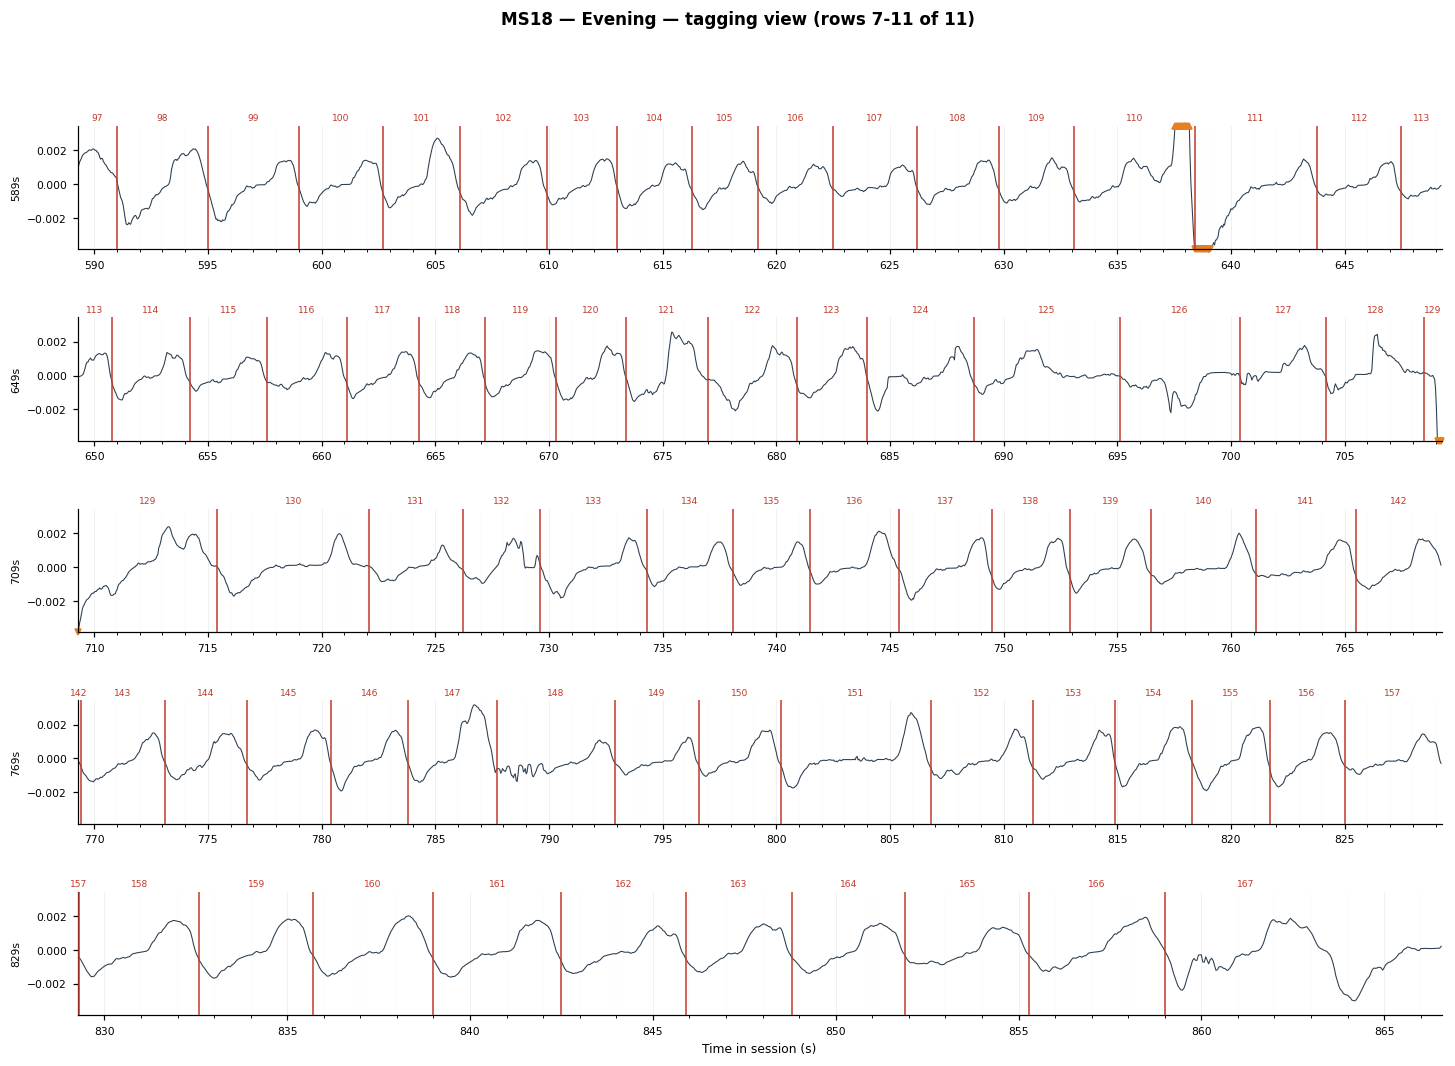

MS18/mor: 129 cycles in 165.1-836.2s  ->  /Users/yotameviatar/Desktop/untitled folder/airflow_output/labeling/MS18_mor_labels.csv


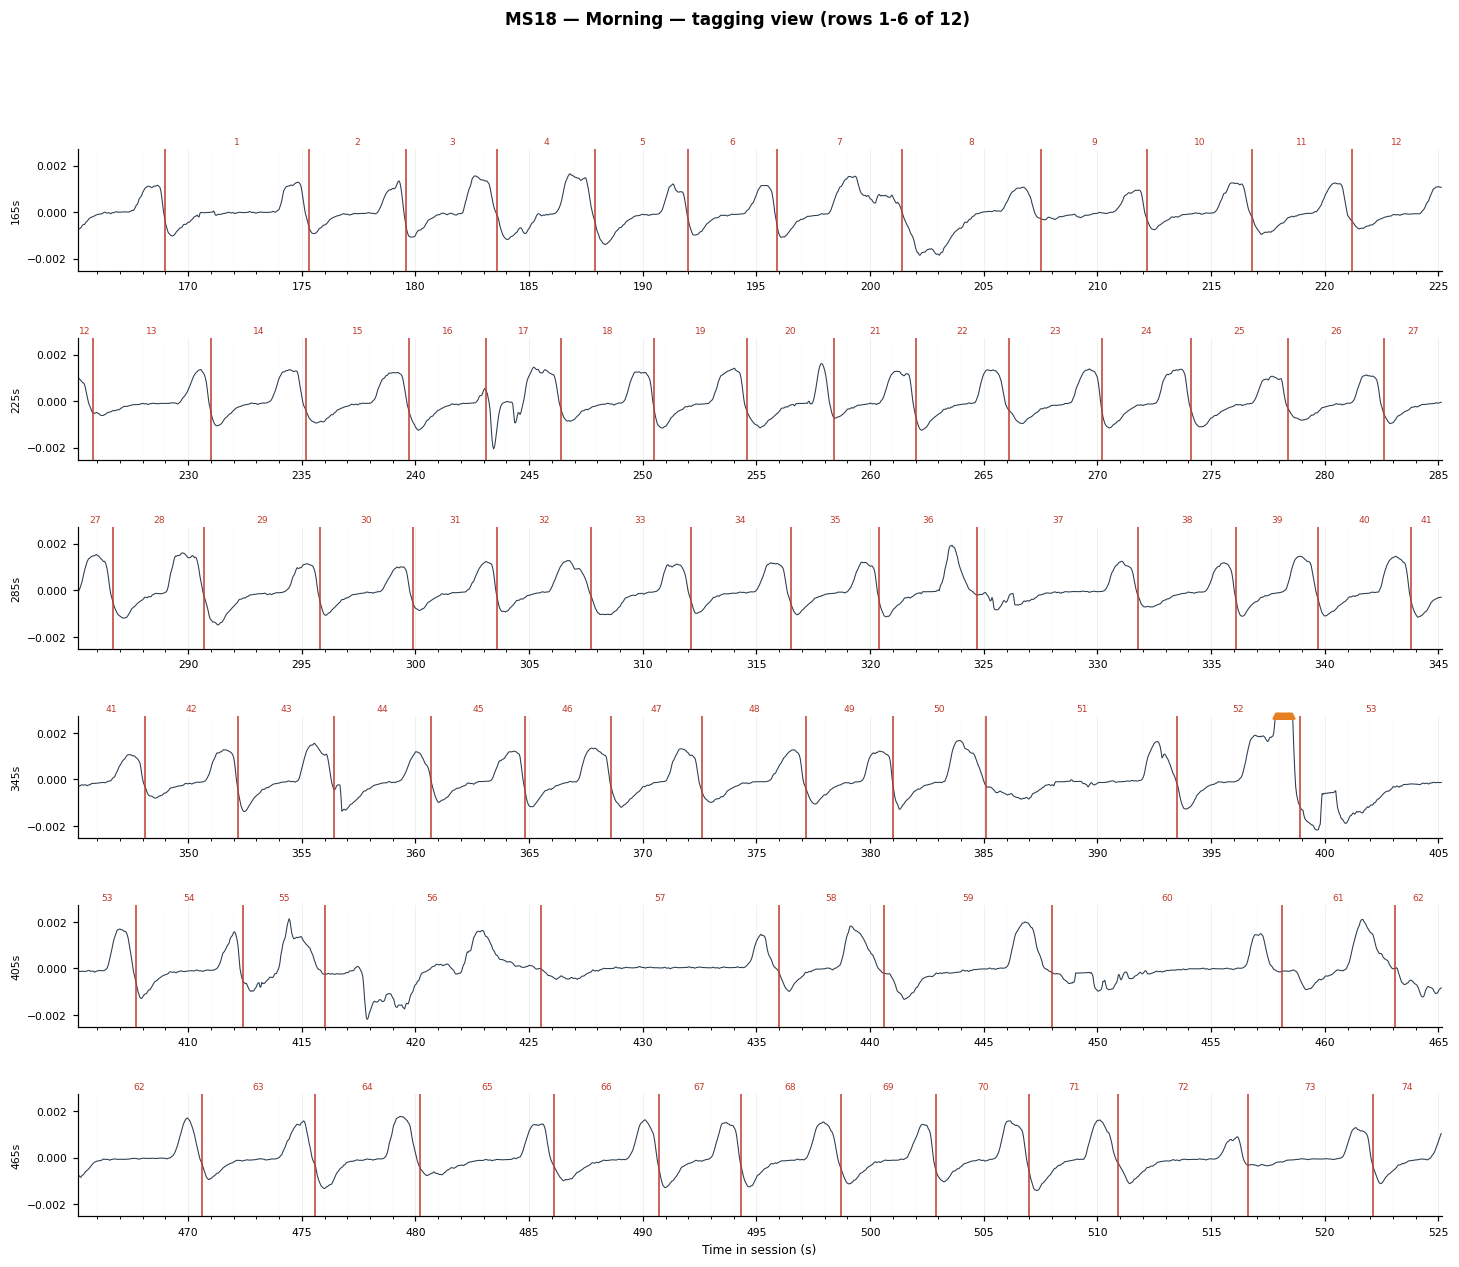

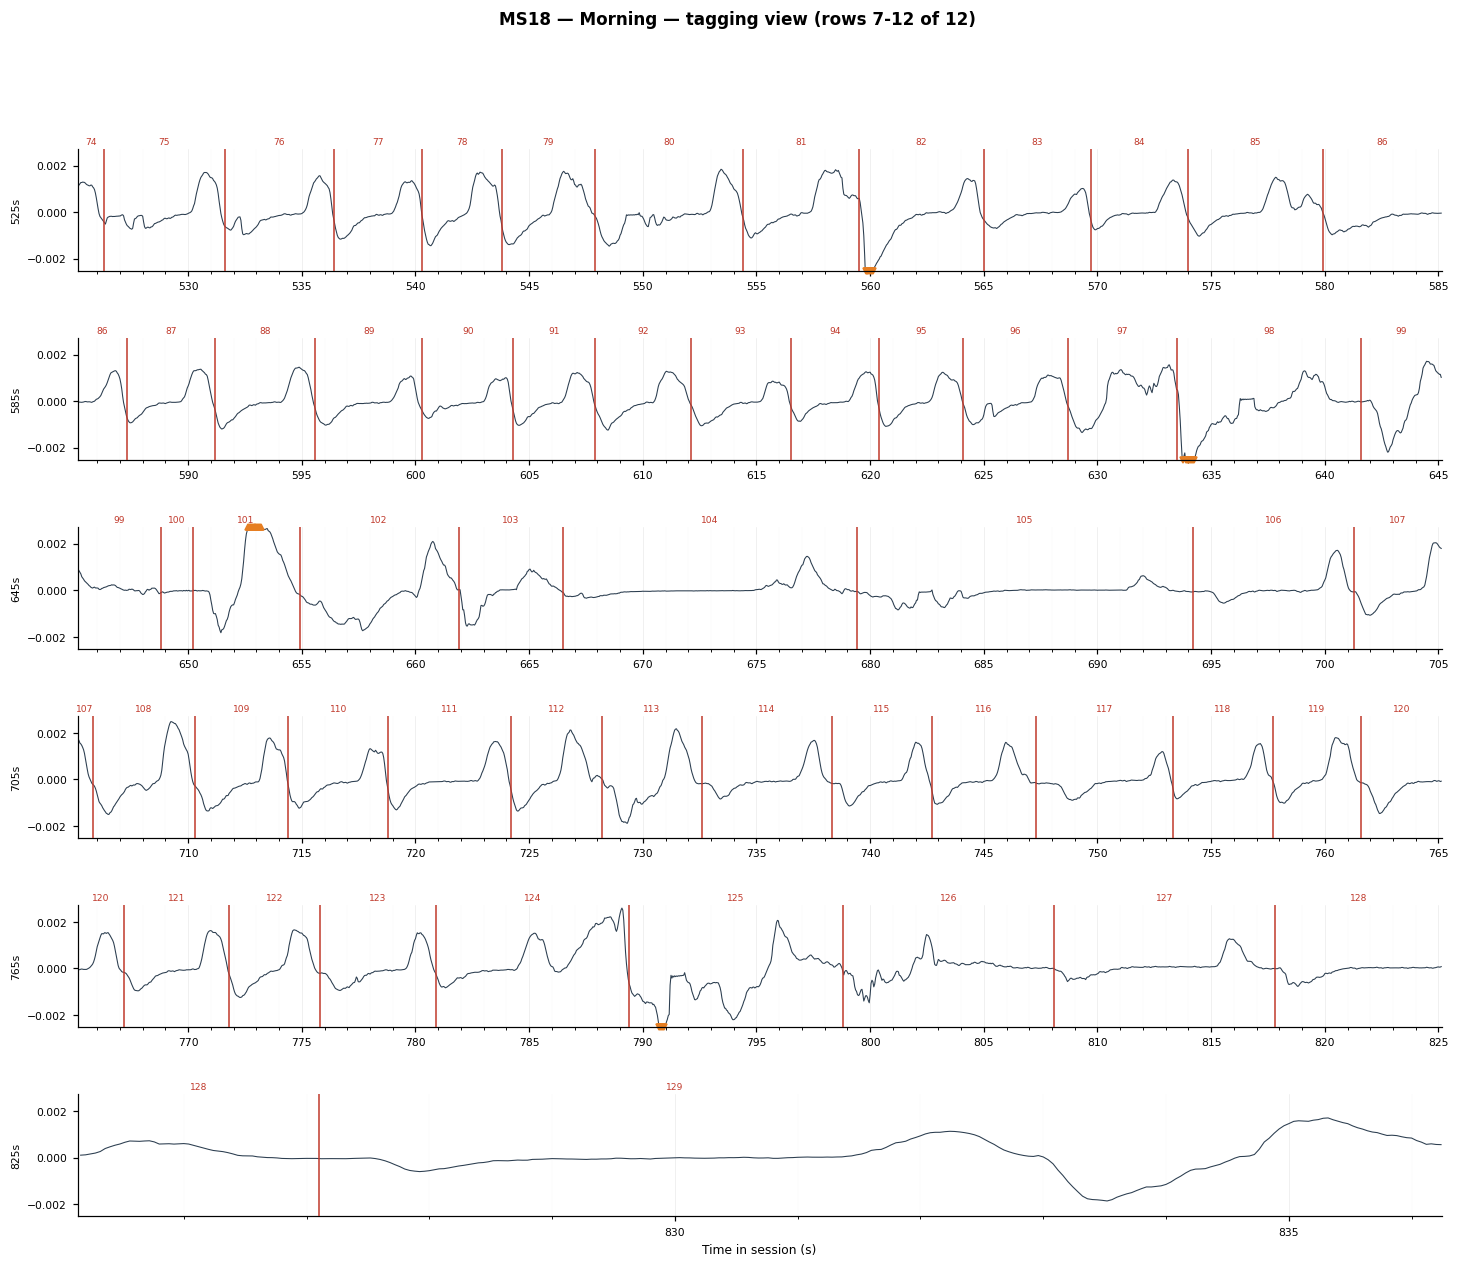

In [108]:
LABEL_ROW_SEC   = 60.0
LABEL_ROWS_PAGE = 6
LABEL_OUT = os.path.join(config.OUTPUT_DIR, "labeling")
os.makedirs(LABEL_OUT, exist_ok=True)


GATE_COLOR = {"extreme": "#C0392B", "recovery": "#E67E22", "gap_fill": "#8E44AD",
              "rate_implausible": "#16A085", "no_inspiration": "#2980B9",
              "lost_lock": "#D35400", "unmeasurable": "#7F8C8D"}


def window_cycles(S):
    ws = S["win_start"] if S["win_start"] is not None else 0.0
    we = S["win_end"] if S["win_end"] is not None else np.inf
    keep = [c["onset_time"] >= ws and c["assign_time"] <= we for c in S["cycles"]]
    cyc = [c for c, k in zip(S["cycles"], keep) if k]
    vrd = [r for r, k in zip(S["reason"], keep) if k]
    return cyc, vrd, ws, we


def write_label_csv(subj, sess_key, S):
    cyc, vrd, ws, we = window_cycles(S)
    path = os.path.join(LABEL_OUT, f"{subj}_{sess_key}_labels.csv")
    with open(path, "w") as f:
        f.write("cycle_id,start_time,end_time,RP,RA_ratio,n_peaks,verdict,bad_start,bad_finish,decision\n")
        med = S["report"]["median_RA"]
        for i, (c, v) in enumerate(zip(cyc, vrd), start=1):
            f.write(f"{i},{c['onset_time']:.2f},{c['assign_time']:.2f},{c['RP']:.2f},"
                    f"{c['RA']/med:.2f},{c.get('n_peaks', -1)},{v or ''},,,\n")
    rep = S["report"]
    print(f"{subj}/{sess_key}: {len(cyc)} cycles in {ws:.1f}-{we:.1f}s  ->  {path}")
    print(f"    kept {100*rep['kept_frac']:.1f}% of breaths, {100*rep['kept_seconds_frac']:.1f}% of seconds"
          f"  |  cut at RA > {rep['cut_RA']/rep['median_RA']:.2f}x median"
          f"  |  gates {rep['gate_counts']}"
          + (f"  |  ABSTAINED {rep['abstained']}" if rep["abstained"] else ""))
    return cyc, vrd, ws, we


def plot_tagging_view(subj, sess_key, S, cyc, vrd, ws, we):
    """Rows of LABEL_ROW_SEC seconds, y in robust-z units of signal_clean.

    Baseline y-limits come from the analysis window's 0.5/99.5 percentiles so
    ordinary breathing looks the same in every row; a row containing anything
    larger EXPANDS to fit it rather than clipping it, so a big artifact shows
    at true size and its magnitude is readable off the ticks."""
    sig = np.asarray(S["signal_clean"], dtype=float)
    sf = S["native_sfreq"]
    t = np.arange(len(sig)) / sf
    inwin = (t >= ws) & (t <= we)

    med = float(np.nanmedian(sig[inwin]))
    mad = float(np.nanmedian(np.abs(sig[inwin] - med))) * 1.4826
    z = (sig - med) / (mad if mad > 0 else 1.0)

    lo, hi = np.percentile(z[inwin], [0.5, 99.5])
    pad = 0.35 * (hi - lo)
    base_lo, base_hi = lo - pad, hi + pad

    bounds = [(i, c["onset_time"], c["assign_time"], v)
              for i, (c, v) in enumerate(zip(cyc, vrd), start=1)]
    n_rows = int(np.ceil((we - ws) / LABEL_ROW_SEC))
    sess_label = config.SESSION_MAP.get(sess_key, {}).get("label", sess_key)

    for p0 in range(0, n_rows, LABEL_ROWS_PAGE):
        rows = list(range(p0, min(p0 + LABEL_ROWS_PAGE, n_rows)))
        fig, axes = plt.subplots(len(rows), 1, figsize=(16, 2.3 * len(rows)),
                                 gridspec_kw=dict(hspace=0.65))
        axes = np.atleast_1d(axes)
        for ax, r in zip(axes, rows):
            t0 = ws + r * LABEL_ROW_SEC
            t1 = min(t0 + LABEL_ROW_SEC, we)
            m = (t >= t0) & (t <= t1)
            zr = z[m]
            ax.axhline(0.0, color="#95A5A6", lw=0.5, ls="--", zorder=1)
            ax.plot(t[m], zr, color="#2C3E50", lw=0.7, zorder=2)

            r_lo = min(base_lo, float(np.nanmin(zr)) * 1.08) if zr.size else base_lo
            r_hi = max(base_hi, float(np.nanmax(zr)) * 1.08) if zr.size else base_hi
            expanded = (r_lo < base_lo - 1e-9) or (r_hi > base_hi + 1e-9)

            for cid, cs, ce, v in bounds:
                if ce < t0 or cs > t1:
                    continue
                col = GATE_COLOR.get(v, "#C0392B") if v else "#95A5A6"
                ax.axvline(cs, color=col if v else "#BDC3C7", lw=1.0,
                           alpha=1.0 if v else 0.7, zorder=3)
                if v:
                    ax.axvspan(max(cs, t0), min(ce, t1), color=col, alpha=0.16, zorder=1)
                mid = 0.5 * (max(cs, t0) + min(ce, t1))
                ax.annotate(str(cid), xy=(mid, 1.0),
                            xycoords=("data", "axes fraction"),
                            xytext=(0, 2), textcoords="offset points",
                            fontsize=6, color=col, ha="center",
                            va="bottom", annotation_clip=False)
                if v:
                    ax.annotate(v, xy=(mid, 0.02), xycoords=("data", "axes fraction"),
                                fontsize=6, color=col, ha="center", va="bottom",
                                annotation_clip=False)

            ax.set_xlim(t0, t1)
            ax.set_ylim(r_lo, r_hi)
            ax.xaxis.set_major_locator(MultipleLocator(5))
            ax.xaxis.set_minor_locator(MultipleLocator(1))
            ax.grid(axis="x", which="major", lw=0.4, alpha=0.30, zorder=0)
            ax.grid(axis="x", which="minor", lw=0.25, alpha=0.12, zorder=0)
            ax.tick_params(labelsize=7)
            peak = float(np.nanmax(np.abs(zr))) if zr.size else 0.0
            ax.set_ylabel(f"{t0:.0f}s\npeak {peak:.0f}z", fontsize=7)
            if expanded:
                ax.axhspan(base_lo, base_hi, color="#3498DB", alpha=0.08, zorder=0)
                for spine in ("left", "bottom"):
                    ax.spines[spine].set_color("#E67E22")
                    ax.spines[spine].set_linewidth(1.4)
            ax.spines[["top", "right"]].set_visible(False)

        axes[-1].set_xlabel("Time in session (s)", fontsize=8)
        fig.suptitle(f"{subj} — {sess_label} — tagging view "
                     f"(rows {rows[0] + 1}-{rows[-1] + 1} of {n_rows}) · "
                     f"y = robust z of signal_raw · shaded = rejected breath, "
                     f"gate name printed · orange frame = row rescaled past the "
                     f"normal band (blue)",
                     fontsize=11, fontweight="bold")
        plt.show()
        plt.close(fig)

for sess_key in sess_keys:
    S = compute_session_qc(SUBJECT, sess_key)
    cyc, vrd, ws, we = write_label_csv(SUBJECT, sess_key, S)
    plot_tagging_view(SUBJECT, sess_key, S, cyc, vrd, ws, we)


## Group-level — sound vs no-sound (session-wide, accepted trials)

In [109]:
_all_trials = [t for sess in trials_data.values() for trials in sess.values()
               for t in trials if t.get("times_anal") is not None and len(t["times_anal"]) > 0]
T_MIN = max(t["times_anal"][0] for t in _all_trials)
T_MAX = min(t["times_anal"][-1] for t in _all_trials)
GRID_DT = 1.0 / config.GLM_TARGET_SFREQ
TIMES_S = np.arange(T_MIN, T_MAX + GRID_DT, GRID_DT)

SND_COLOR, NOS_COLOR = "#27AE60", "#7F8C8D"

def _group_curve(sess_key, want_sound):
    subj_avgs = []
    n_subj = n_trials = 0
    for subj, sessions in trials_data.items():
        trials = sessions.get(sess_key, [])
        cond_trials = [
            t for t in trials
            if not t.get("rejected")
            and t.get("epoch_anal") is not None
            and t.get("baseline_mean") is not None
            and np.isfinite(t["baseline_mean"])
            and bool(t.get("has_sound")) == want_sound
        ]
        if not cond_trials:
            continue
        arr = np.array([
            np.interp(TIMES_S, t["times_anal"], t["epoch_anal"] - t["baseline_mean"],
                      left=np.nan, right=np.nan)
            for t in cond_trials
        ])
        subj_avgs.append(np.nanmean(arr, axis=0))
        n_subj += 1
        n_trials += len(cond_trials)
    if not subj_avgs:
        return None
    arr2 = np.array(subj_avgs)
    avg = np.nanmean(arr2, axis=0)
    sem = _stats.sem(arr2, axis=0, nan_policy="omit") if len(subj_avgs) > 1 else np.zeros_like(avg)
    return dict(avg=avg, sem=sem, n_subj=n_subj, n_trials=n_trials)

def _reaction(t):
    ep = np.asarray(t["epoch_anal"], float)
    tw = np.asarray(t["times_anal"], float)
    base, resp = ep[tw < 0], ep[tw >= 0]
    if base.size < 2 or resp.size < 2:
        return None
    return float(np.mean(resp) - np.mean(base))

def _sound_stats(sess_key):
    rows = []
    for subj, sessions in trials_data.items():
        trials = sessions.get(sess_key, [])
        snd, nos = [], []
        for t in trials:
            if t.get("rejected") or t.get("epoch_anal") is None:
                continue
            v = _reaction(t)
            if v is None:
                continue
            (snd if t.get("has_sound") else nos).append(v)
        if snd and nos:
            rows.append((subj, float(np.mean(snd)), float(np.mean(nos))))
    if len(rows) < 2:
        return None
    a = np.array([r[1] for r in rows])
    b = np.array([r[2] for r in rows])
    w, p = _stats.wilcoxon(a, b)
    return dict(n=len(rows), w=w, p=p, mean_diff=float(np.mean(a - b)))


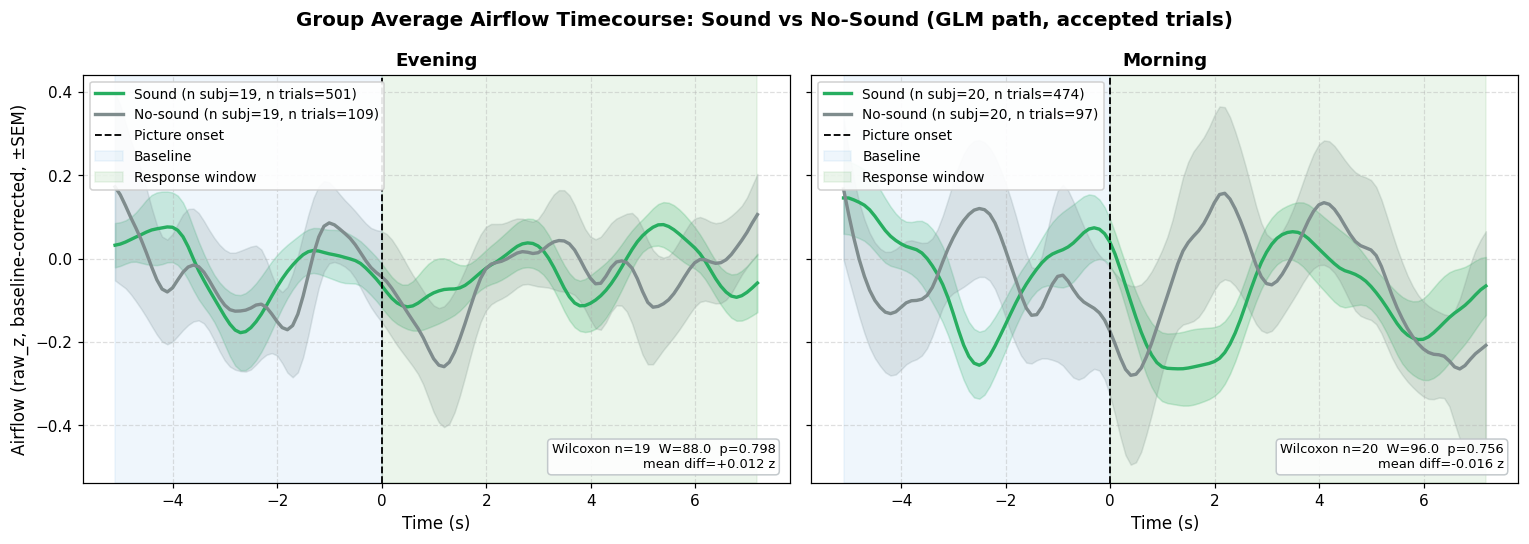

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Group Average Airflow Timecourse: Sound vs No-Sound (GLM path, accepted trials)",
             fontsize=13, fontweight="bold")

for ax, sess_key in zip(axes, ["eve", "mor"]):
    sess_label = config.SESSION_MAP.get(sess_key, {}).get("label", sess_key)
    snd = _group_curve(sess_key, True)
    nos = _group_curve(sess_key, False)

    if snd is not None:
        ax.plot(TIMES_S, snd["avg"], color=SND_COLOR, linewidth=2.2,
                label=f"Sound (n subj={snd['n_subj']}, n trials={snd['n_trials']})")
        ax.fill_between(TIMES_S, snd["avg"] - snd["sem"], snd["avg"] + snd["sem"],
                         color=SND_COLOR, alpha=0.20)
    if nos is not None:
        ax.plot(TIMES_S, nos["avg"], color=NOS_COLOR, linewidth=2.2,
                label=f"No-sound (n subj={nos['n_subj']}, n trials={nos['n_trials']})")
        ax.fill_between(TIMES_S, nos["avg"] - nos["sem"], nos["avg"] + nos["sem"],
                         color=NOS_COLOR, alpha=0.20)

    ax.axvline(0, color="k", linestyle="--", linewidth=1.2, label="Picture onset")
    ax.axvspan(TIMES_S[0], 0.0, color="#3498DB", alpha=0.08, label="Baseline")
    ax.axvspan(0.0, TIMES_S[-1], color="green", alpha=0.08, label="Response window")

    stats = _sound_stats(sess_key)
    if stats is not None:
        ax.text(0.98, 0.03,
                f"Wilcoxon n={stats['n']}  W={stats['w']:.1f}  p={stats['p']:.3f}\n"
                f"mean diff={stats['mean_diff']:+.3f} z",
                transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#BDC3C7", alpha=0.9))

    ax.set_title(sess_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Time (s)", fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel("Airflow (raw_z, baseline-corrected, ±SEM)", fontsize=11)
    ax.legend(fontsize=9, framealpha=0.9, loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
plt.close(fig)


### Indicative — 5 example subjects, sound vs no-sound timecourse

Indicative subjects: ['AB22', 'AG05', 'AH19', 'AK12', 'AS09']


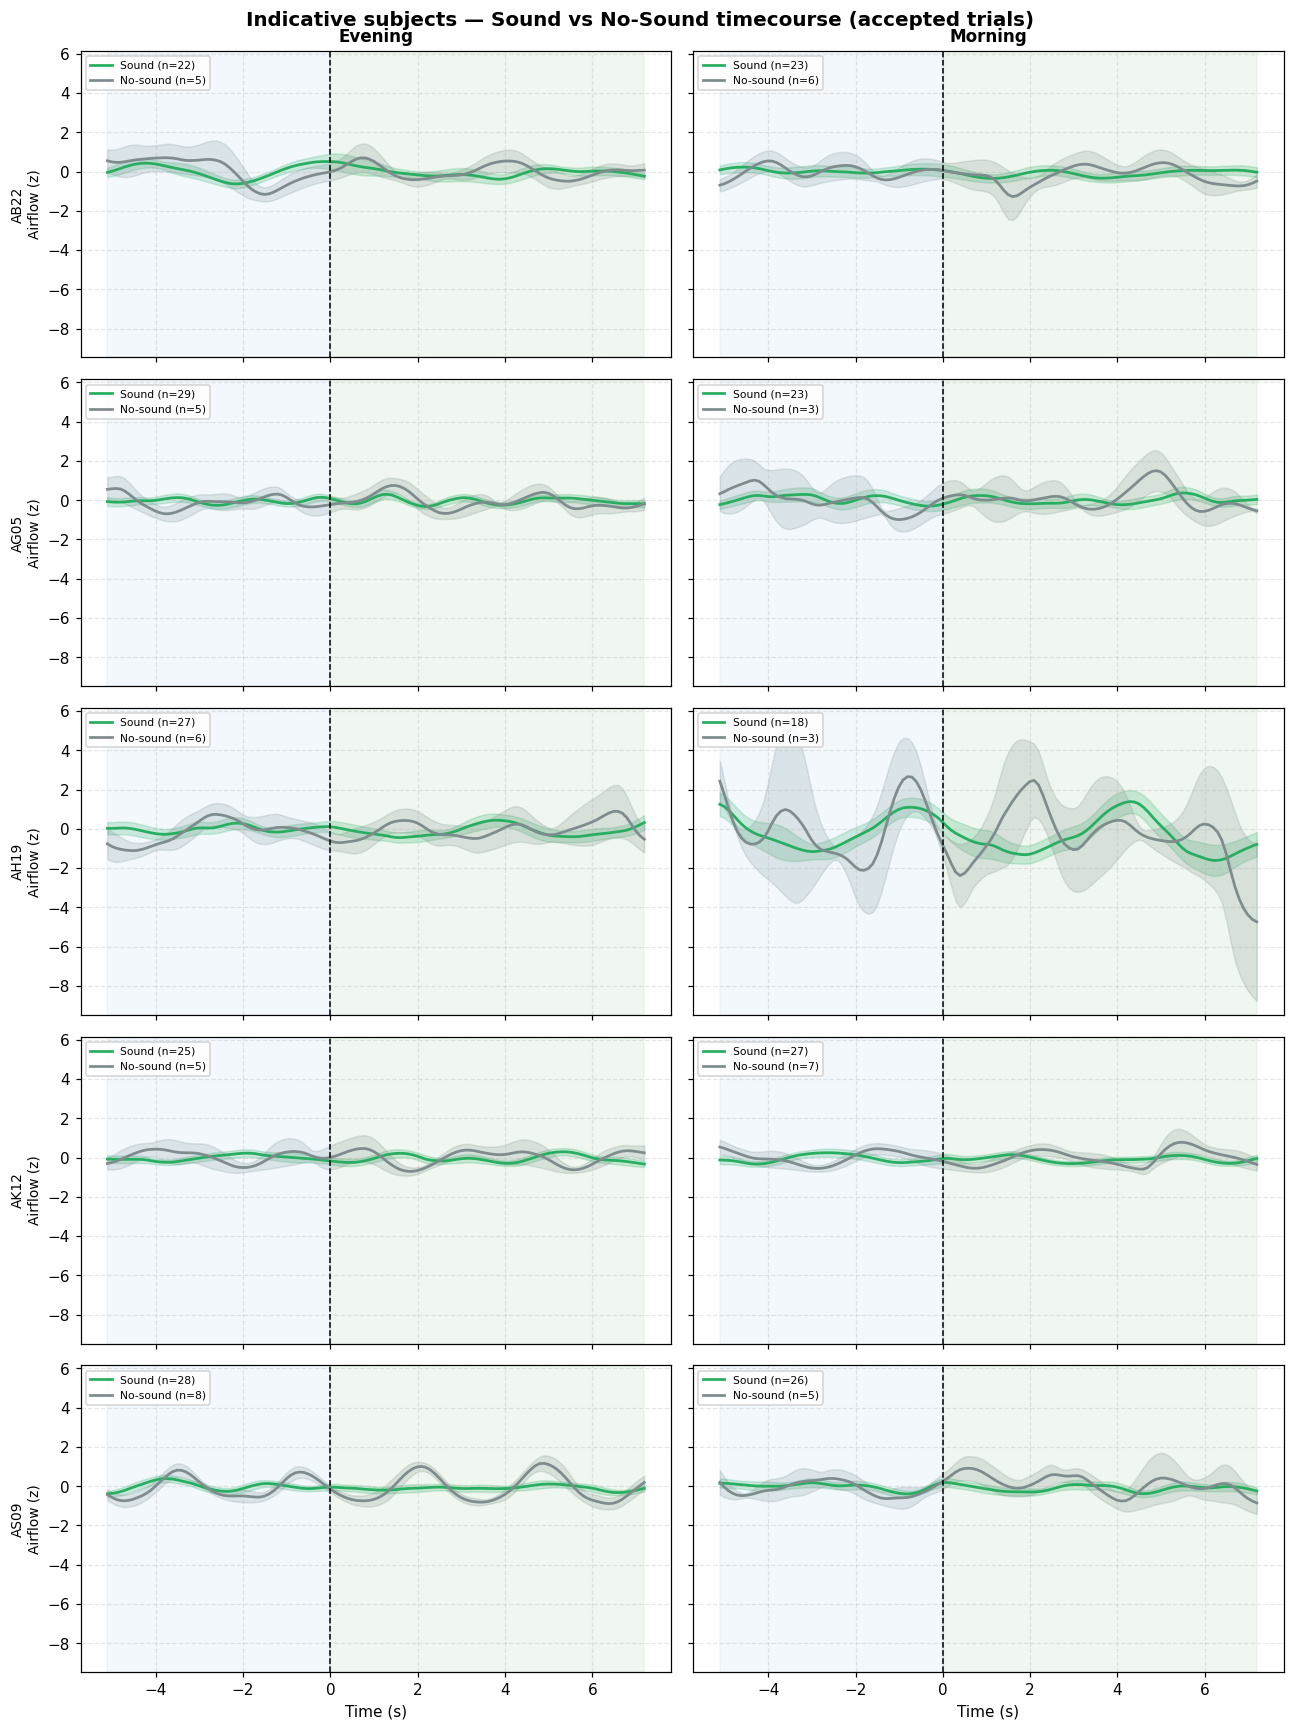

In [111]:
def _pick_indicative_subjects(n=5):
    candidates = []
    for subj, sessions in trials_data.items():
        ok = True
        for sk in ("eve", "mor"):
            trials = sessions.get(sk, [])
            has_snd = any(not t.get("rejected") and t.get("has_sound") for t in trials)
            has_nos = any(not t.get("rejected") and not t.get("has_sound") for t in trials)
            ok = ok and has_snd and has_nos
        if ok:
            candidates.append(subj)
    return sorted(candidates)[:n]

INDICATIVE_SUBJECTS = _pick_indicative_subjects(5)
print("Indicative subjects:", INDICATIVE_SUBJECTS)

def _subject_curve(subj, sess_key, want_sound):
    trials = trials_data.get(subj, {}).get(sess_key, [])
    cond_trials = [
        t for t in trials
        if not t.get("rejected")
        and t.get("epoch_anal") is not None
        and t.get("baseline_mean") is not None
        and np.isfinite(t["baseline_mean"])
        and bool(t.get("has_sound")) == want_sound
    ]
    if not cond_trials:
        return None
    arr = np.array([
        np.interp(TIMES_S, t["times_anal"], t["epoch_anal"] - t["baseline_mean"],
                  left=np.nan, right=np.nan)
        for t in cond_trials
    ])
    avg = np.nanmean(arr, axis=0)
    sem = _stats.sem(arr, axis=0, nan_policy="omit") if len(cond_trials) > 1 else np.zeros_like(avg)
    return dict(avg=avg, sem=sem, n=len(cond_trials))

fig, axes = plt.subplots(len(INDICATIVE_SUBJECTS), 2, figsize=(12, 3.2 * len(INDICATIVE_SUBJECTS)),
                         sharex=True, sharey=True, squeeze=False)
fig.suptitle("Indicative subjects — Sound vs No-Sound timecourse (accepted trials)",
             fontsize=13, fontweight="bold")

for row, subj in enumerate(INDICATIVE_SUBJECTS):
    for col, sess_key in enumerate(["eve", "mor"]):
        ax = axes[row, col]
        sess_label = config.SESSION_MAP.get(sess_key, {}).get("label", sess_key)
        snd = _subject_curve(subj, sess_key, True)
        nos = _subject_curve(subj, sess_key, False)

        if snd is not None:
            ax.plot(TIMES_S, snd["avg"], color=SND_COLOR, linewidth=1.8, label=f"Sound (n={snd['n']})")
            ax.fill_between(TIMES_S, snd["avg"] - snd["sem"], snd["avg"] + snd["sem"],
                             color=SND_COLOR, alpha=0.20)
        if nos is not None:
            ax.plot(TIMES_S, nos["avg"], color=NOS_COLOR, linewidth=1.8, label=f"No-sound (n={nos['n']})")
            ax.fill_between(TIMES_S, nos["avg"] - nos["sem"], nos["avg"] + nos["sem"],
                             color=NOS_COLOR, alpha=0.20)

        ax.axvline(0, color="k", linestyle="--", linewidth=1.0)
        ax.axvspan(TIMES_S[0], 0.0, color="#3498DB", alpha=0.06)
        ax.axvspan(0.0, TIMES_S[-1], color="green", alpha=0.06)

        if row == 0:
            ax.set_title(sess_label, fontsize=11, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{subj}\nAirflow (z)", fontsize=9)
        ax.legend(fontsize=7, framealpha=0.85, loc="upper left")
        ax.grid(True, linestyle="--", alpha=0.3)

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()
plt.close(fig)


### Group overall — ALL trials pooled (no sound split), Evening vs Morning

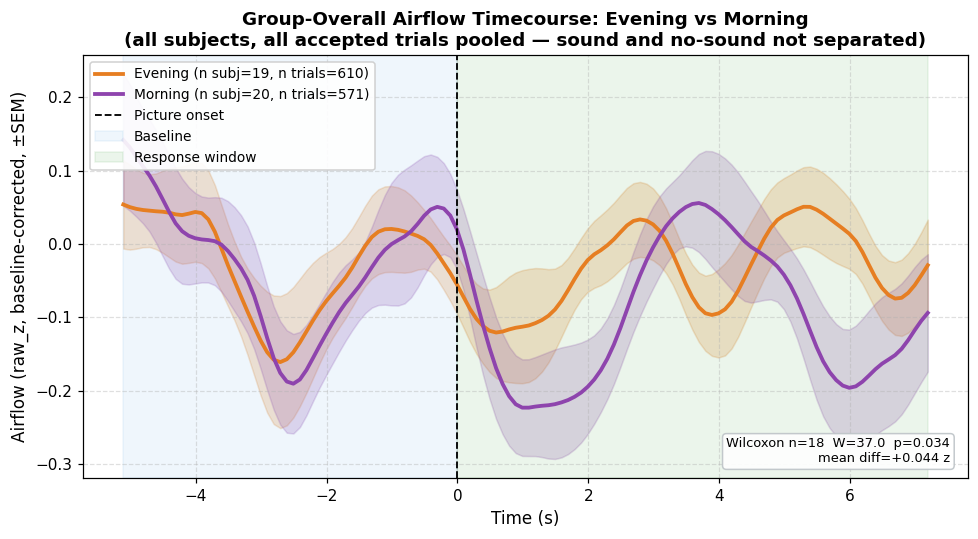

In [112]:
def _group_curve_all(sess_key):
    subj_avgs = []
    n_subj = n_trials = 0
    for subj, sessions in trials_data.items():
        trials = sessions.get(sess_key, [])
        cond_trials = [
            t for t in trials
            if not t.get("rejected")
            and t.get("epoch_anal") is not None
            and t.get("baseline_mean") is not None
            and np.isfinite(t["baseline_mean"])
        ]
        if not cond_trials:
            continue
        arr = np.array([
            np.interp(TIMES_S, t["times_anal"], t["epoch_anal"] - t["baseline_mean"],
                      left=np.nan, right=np.nan)
            for t in cond_trials
        ])
        subj_avgs.append(np.nanmean(arr, axis=0))
        n_subj += 1
        n_trials += len(cond_trials)
    if not subj_avgs:
        return None
    arr2 = np.array(subj_avgs)
    avg = np.nanmean(arr2, axis=0)
    sem = _stats.sem(arr2, axis=0, nan_policy="omit") if len(subj_avgs) > 1 else np.zeros_like(avg)
    return dict(avg=avg, sem=sem, n_subj=n_subj, n_trials=n_trials)

def _all_reaction_stats():
    rows = []
    for subj, sessions in trials_data.items():
        eve_r, mor_r = [], []
        for t in sessions.get("eve", []):
            if t.get("rejected") or t.get("epoch_anal") is None:
                continue
            v = _reaction(t)
            if v is not None:
                eve_r.append(v)
        for t in sessions.get("mor", []):
            if t.get("rejected") or t.get("epoch_anal") is None:
                continue
            v = _reaction(t)
            if v is not None:
                mor_r.append(v)
        if eve_r and mor_r:
            rows.append((subj, float(np.mean(eve_r)), float(np.mean(mor_r))))
    if len(rows) < 2:
        return None
    a = np.array([r[1] for r in rows])
    b = np.array([r[2] for r in rows])
    w, p = _stats.wilcoxon(a, b)
    return dict(n=len(rows), w=w, p=p, mean_diff=float(np.mean(a - b)))

fig, ax = plt.subplots(figsize=(9, 5))
for sess_key, sess_label, color in [("eve", "Evening", config.EVE_COLOR),
                                     ("mor", "Morning", config.MOR_COLOR)]:
    G = _group_curve_all(sess_key)
    if G is None:
        continue
    ax.plot(TIMES_S, G["avg"], color=color, linewidth=2.5,
            label=f"{sess_label} (n subj={G['n_subj']}, n trials={G['n_trials']})")
    ax.fill_between(TIMES_S, G["avg"] - G["sem"], G["avg"] + G["sem"], color=color, alpha=0.20)

ax.axvline(0, color="k", linestyle="--", linewidth=1.2, label="Picture onset")
ax.axvspan(TIMES_S[0], 0.0, color="#3498DB", alpha=0.08, label="Baseline")
ax.axvspan(0.0, TIMES_S[-1], color="green", alpha=0.08, label="Response window")

stats_all = _all_reaction_stats()
if stats_all is not None:
    ax.text(0.98, 0.03,
            f"Wilcoxon n={stats_all['n']}  W={stats_all['w']:.1f}  p={stats_all['p']:.3f}\n"
            f"mean diff={stats_all['mean_diff']:+.3f} z",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#BDC3C7", alpha=0.9))

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Airflow (raw_z, baseline-corrected, ±SEM)", fontsize=11)
ax.set_title("Group-Overall Airflow Timecourse: Evening vs Morning\n"
             "(all subjects, all accepted trials pooled — sound and no-sound not separated)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.9, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
plt.close(fig)


### Sound-conditioned GLM score — Evening vs Morning boxplots (Sound-only, No-sound-only)

`score_{metric}` in `trials_data` is fit against `config.GLM_CONDITION_FIELD` (Negative/Neutral by default), not Sound/No-sound -- refits the pooled-session GLM per subject/session with condition reassigned to Sound(1)/No-sound(2) so the two boxplots below reflect a genuinely sound-conditioned score, not a same-value split of the label-conditioned one.

In [113]:
_qc_memo = globals().get("_qc_memo", {})

def compute_session_qc_memo(subj, sess_key):
    key = (subj, sess_key)
    if key not in _qc_memo:
        _qc_memo[key] = compute_session_qc(subj, sess_key)
    return _qc_memo[key]

def compute_sound_conditioned_scores(metric):
    cache_path = os.path.join(config.OUTPUT_DIR, "_cache",
                              f"glm_sound_scoring_{metric}_{_config_fingerprint()}.pkl")
    if os.path.exists(cache_path) and not FORCE_RESCORE:
        with open(cache_path, "rb") as f:
            print(f"Loaded cached sound-conditioned scores: {os.path.basename(cache_path)}")
            return pickle.load(f)

    print("Refitting pooled-session GLM with condition=has_sound (first time only, then cached) ...")
    scores = {}
    key = f"score_{metric.lower()}"
    for subj, sess_dict in trials_data.items():
        scores[subj] = {}
        for sess_key, trials in sess_dict.items():
            if not trials:
                continue
            S = compute_session_qc_memo(subj, sess_key)
            trials_copy = [dict(t, condition=(1 if t["has_sound"] else 2)) for t in trials]
            glm.fit_pooled_session_glm(trials_copy, S["series"], S["sfreq"], config)

            snd_vals = [t[key] for t in trials_copy
                        if not t["rejected"] and t["condition"] == 1
                        and t.get(key) is not None and np.isfinite(t[key])]
            nos_vals = [t[key] for t in trials_copy
                        if not t["rejected"] and t["condition"] == 2
                        and t.get(key) is not None and np.isfinite(t[key])]
            scores[subj][sess_key] = {
                "sound":   float(np.mean(snd_vals)) if snd_vals else np.nan,
                "nosound": float(np.mean(nos_vals)) if nos_vals else np.nan,
            }

    with open(cache_path, "wb") as f:
        pickle.dump(scores, f)
    print(f"Scored and cached: {os.path.basename(cache_path)}")
    return scores

sound_scores = compute_sound_conditioned_scores(METRIC)


def get_subject_zscored_series(subj):
    sess_dict = trials_data.get(subj, {})
    present = [sk for sk in sess_dict if sess_dict[sk]]
    raw = {sk: compute_session_qc_memo(subj, sk) for sk in present}
    zseries = glm.zscore_subject_series({sk: S["series"] for sk, S in raw.items()}, config)
    return {sk: {"series": zseries[sk], "sfreq": raw[sk]["sfreq"]} for sk in present}


Loaded cached sound-conditioned scores: glm_sound_scoring_RA_10a9293d1074.pkl


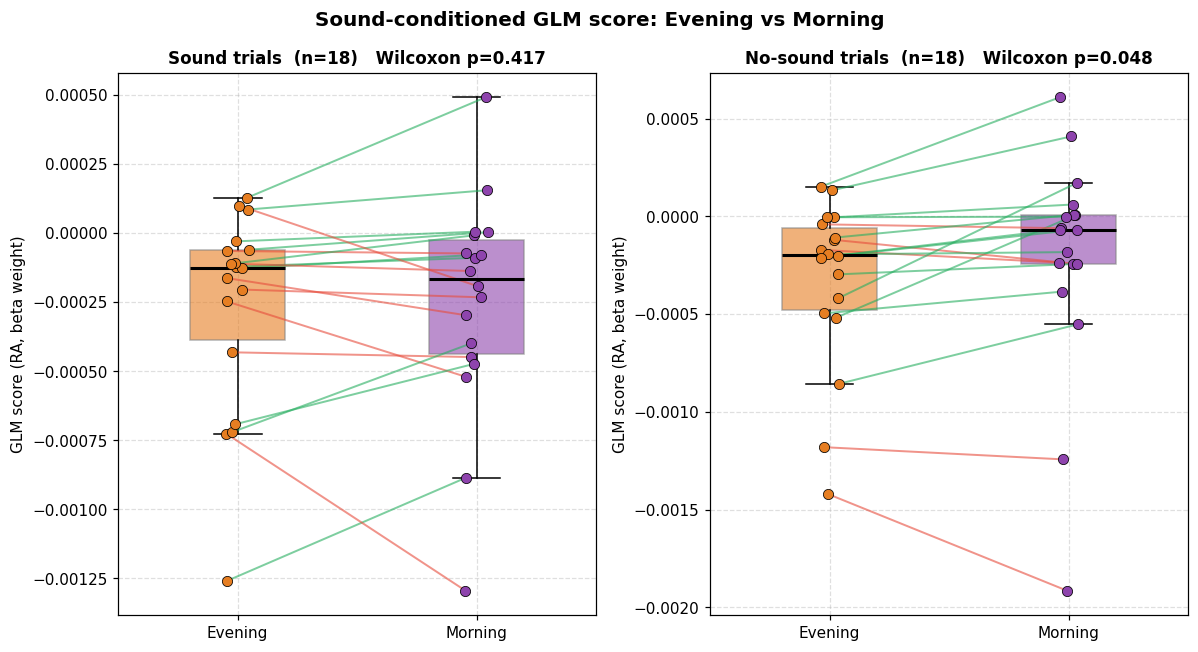

In [114]:
def _paired_test(a, b):
    try:
        stat, p = _stats.wilcoxon(a, b)
        return stat, p, "Wilcoxon"
    except Exception:
        stat, p = _stats.ttest_rel(a, b)
        return stat, p, "Paired t"

def _eve_mor_pairs(cond_key):
    rows = []
    for subj, sess in sound_scores.items():
        e = sess.get("eve", {}).get(cond_key)
        m = sess.get("mor", {}).get(cond_key)
        if e is not None and m is not None and np.isfinite(e) and np.isfinite(m):
            rows.append((subj, e, m))
    return rows

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, cond_key, title in zip(axes, ["sound", "nosound"], ["Sound trials", "No-sound trials"]):
    rows = _eve_mor_pairs(cond_key)
    if len(rows) < 2:
        ax.set_title(f"{title} — insufficient paired data")
        continue

    eve_vals = [r[1] for r in rows]
    mor_vals = [r[2] for r in rows]
    stat, p, label = _paired_test(eve_vals, mor_vals)

    bp = ax.boxplot([eve_vals, mor_vals], positions=[1, 2], widths=0.4,
                    patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], [config.EVE_COLOR, config.MOR_COLOR]):
        patch.set_facecolor(color); patch.set_alpha(0.6); patch.set_edgecolor("gray")
    for median in bp["medians"]:
        median.set(color="black", linewidth=2)

    for ev, mo in zip(eve_vals, mor_vals):
        j = np.random.uniform(-0.05, 0.05)
        lc = config.UP_COLOR if mo >= ev else config.DOWN_COLOR
        ax.plot([1 + j, 2 + j], [ev, mo], color=lc, alpha=0.6, linewidth=1.3)
        ax.scatter(1 + j, ev, color=config.EVE_COLOR, edgecolors="k", s=45, zorder=3, linewidths=0.5)
        ax.scatter(2 + j, mo, color=config.MOR_COLOR, edgecolors="k", s=45, zorder=3, linewidths=0.5)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Evening", "Morning"])
    ax.set_ylabel(f"GLM score ({METRIC}, beta weight)")
    ax.set_title(f"{title}  (n={len(rows)})   {label} p={p:.3f}", fontsize=11, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Sound-conditioned GLM score: Evening vs Morning", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close(fig)


### Metric timecourse — RP / RA / RFR, Sound vs No-sound, Evening vs Morning

Same GLM-path trials as above, but plotted on the actual scored series (`series[metric]`, Stage 5) instead of the raw `raw_z` waveform — one panel per metric, baseline-corrected the same way as the raw-signal plots.

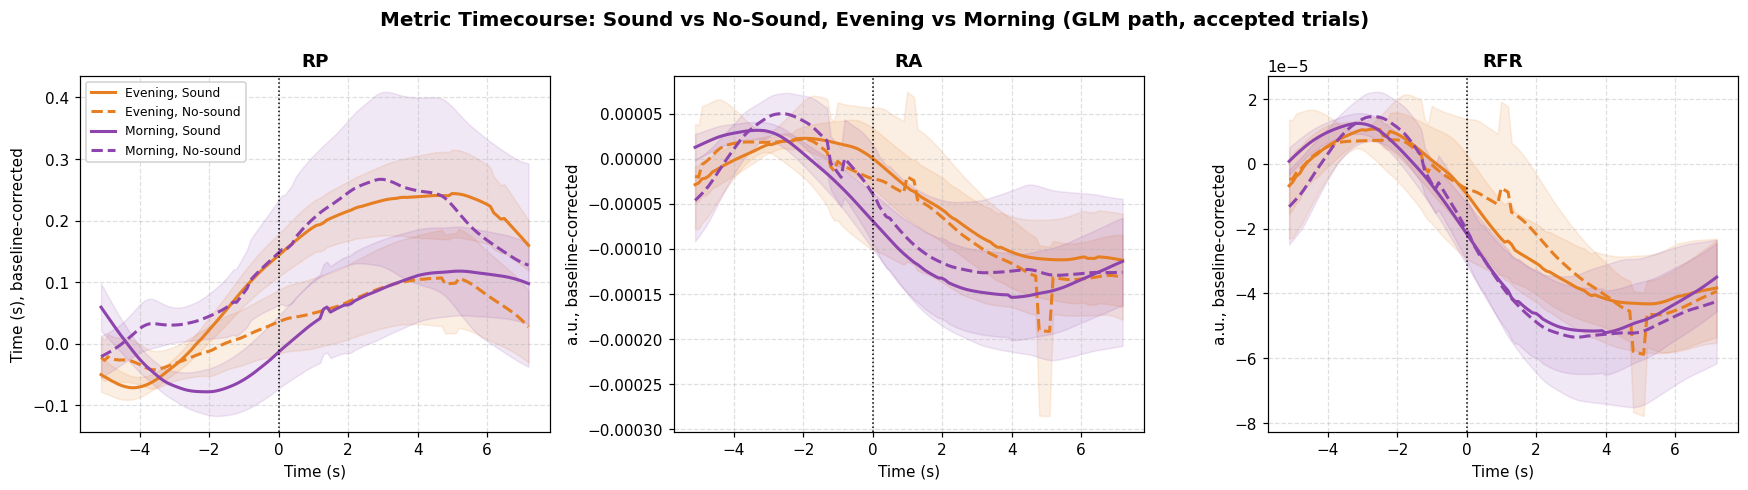

In [115]:
METRICS_PANEL = ["RP", "RA", "RFR"]
METRIC_UNITS = {"RP": "Time (s)", "RA": "a.u.", "RFR": "a.u."}

def _metric_curve(metric, sess_key, want_sound):
    subj_avgs = []
    n_subj = n_trials = 0
    for subj, sessions in trials_data.items():
        trials = sessions.get(sess_key, [])
        cond_trials = [
            t for t in trials
            if not t.get("rejected")
            and bool(t.get("has_sound")) == want_sound
        ]
        if not cond_trials:
            continue
        S = compute_session_qc_memo(subj, sess_key)
        y_full = S["series"][metric]
        rows = []
        for t in cond_trials:
            i0, i1 = t["win_start_idx"], t["win_end_idx"]
            tw = t["times_wide"]
            y = y_full[i0:i1]
            if len(y) != len(tw):
                continue
            pre = tw < 0
            if np.sum(np.isfinite(y[pre])) < 2:
                continue
            base = np.nanmean(y[pre])
            rows.append(np.interp(TIMES_S, tw, y - base, left=np.nan, right=np.nan))
        if not rows:
            continue
        subj_avgs.append(np.nanmean(np.array(rows), axis=0))
        n_subj += 1
        n_trials += len(rows)
    if not subj_avgs:
        return None
    arr = np.array(subj_avgs)
    avg = np.nanmean(arr, axis=0)
    sem = _stats.sem(arr, axis=0, nan_policy="omit") if len(subj_avgs) > 1 else np.zeros_like(avg)
    return dict(avg=avg, sem=sem, n_subj=n_subj, n_trials=n_trials)

_line_style = {
    ("eve", True):  dict(color=config.EVE_COLOR, linestyle="-",  label="Evening, Sound"),
    ("eve", False): dict(color=config.EVE_COLOR, linestyle="--", label="Evening, No-sound"),
    ("mor", True):  dict(color=config.MOR_COLOR, linestyle="-",  label="Morning, Sound"),
    ("mor", False): dict(color=config.MOR_COLOR, linestyle="--", label="Morning, No-sound"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Metric Timecourse: Sound vs No-Sound, Evening vs Morning (GLM path, accepted trials)",
             fontsize=13, fontweight="bold")

for ax, metric in zip(axes, METRICS_PANEL):
    for sess_key in ("eve", "mor"):
        for want_sound in (True, False):
            G = _metric_curve(metric, sess_key, want_sound)
            if G is None:
                continue
            style = _line_style[(sess_key, want_sound)]
            ax.plot(TIMES_S, G["avg"], linewidth=2.0, **style)
            ax.fill_between(TIMES_S, G["avg"] - G["sem"], G["avg"] + G["sem"],
                             color=style["color"], alpha=0.12)
    ax.axvline(0, color="k", linestyle=":", linewidth=1.0)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.set_ylabel(f"{METRIC_UNITS[metric]}, baseline-corrected", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    if ax is axes[0]:
        ax.legend(fontsize=8, framealpha=0.9, loc="upper left")

plt.tight_layout()
plt.show()
plt.close(fig)


### Score summary table — RP / RA / RFR, Sound vs No-sound, Evening vs Morning

Mean ± SEM of the pooled-session GLM score (`score_{metric}`, condition = `has_sound`), same refit as the boxplots above, run for all three metrics.

In [116]:
import pandas as pd

_all_metric_scores = {m: compute_sound_conditioned_scores(m) for m in METRICS_PANEL}

def _summary_row(metric):
    scores = _all_metric_scores[metric]
    row = {"Metric": metric}
    for sess_key, sess_label in [("eve", "Evening"), ("mor", "Morning")]:
        for cond_key, cond_label in [("sound", "Sound"), ("nosound", "No-sound")]:
            vals = [sess.get(sess_key, {}).get(cond_key) for sess in scores.values()]
            vals = np.array([v for v in vals if v is not None and np.isfinite(v)])
            col = f"{sess_label} — {cond_label}"
            row[col] = f"{vals.mean():.3g} ± {_stats.sem(vals):.3g}  (n={len(vals)})" if len(vals) else "n/a"
    return row

summary_table = pd.DataFrame([_summary_row(m) for m in METRICS_PANEL]).set_index("Metric")
summary_table


Loaded cached sound-conditioned scores: glm_sound_scoring_RP_10a9293d1074.pkl
Loaded cached sound-conditioned scores: glm_sound_scoring_RA_10a9293d1074.pkl
Loaded cached sound-conditioned scores: glm_sound_scoring_RFR_10a9293d1074.pkl


,Evening — Sound,Evening — No-sound,Morning — Sound,Morning — No-sound
Metric,,,,
RP,-0.0597 ± 0.0758 (n=19),-0.166 ± 0.0767 (n=19),-0.41 ± 0.102 (n=20),-0.0912 ± 0.111 (n=20)
RA,-0.000249 ± 8.29e-05 (n=19),-0.000311 ± 9.83e-05 (n=19),-0.000281 ± 8.7e-05 (n=20),-0.000289 ± 0.000131 (n=20)
RFR,-2.9e-05 ± 1.78e-05 (n=19),-4.55e-05 ± 1.38e-05 (n=19),-1.56e-05 ± 1.34e-05 (n=20),-2.25e-05 ± 2.35e-05 (n=20)


## Full pipeline walk — one subject, Evening vs Morning side by side

Rows: Stage 2c (`raw_z`) · Stage 4 (`series[METRIC]`) · CRF vs. trial epochs · Stage 5 GLM fit.


In [117]:
WALK_SUBJECT = SUBJECT
WALK_METRIC  = METRIC  # fitted/series capture in fit_pooled_session_glm is only wired for RA

zdata_walk = get_subject_zscored_series(WALK_SUBJECT)

N_ROWS = 4
fig, axes = plt.subplots(N_ROWS, 2, figsize=(16, 13), sharex=False,
                          gridspec_kw=dict(hspace=0.55, top=0.955, bottom=0.04))
axes[0, 0].sharey(axes[0, 1])
fig.suptitle(f"{WALK_SUBJECT} \u2014 single-condition {WALK_METRIC} score: full pipeline walk",
             fontsize=13, fontweight="bold", y=0.99)

walk_scores = {}

for col, sess_key in enumerate(["eve", "mor"]):
    row_axes = [axes[r, col] for r in range(N_ROWS)]
    ax_z, ax_series, ax_crf, ax_fit = row_axes
    sess_label = config.SESSION_MAP.get(sess_key, {}).get("label", sess_key)

    if sess_key not in sess_keys or sess_key not in zdata_walk:
        for ax in row_axes:
            ax.set_visible(False)
        continue

    S = compute_session_qc_memo(WALK_SUBJECT, sess_key)
    trials = trials_data.get(WALK_SUBJECT, {}).get(sess_key, [])

    # Force single condition and refit on a COPY -- identical to
    # compute_single_condition_scores, but kept local so trials_data/single_scores
    # are never mutated by this diagnostic cell.
    trials_copy = [dict(t, condition=1) for t in trials]
    glm.fit_pooled_session_glm(trials_copy, zdata_walk[sess_key]["series"],
                                zdata_walk[sess_key]["sfreq"], config)

    key = f"score_{WALK_METRIC.lower()}"
    vals = [t[key] for t in trials_copy
            if not t["rejected"] and t.get(key) is not None and np.isfinite(t[key])]
    score = float(np.mean(vals)) if vals else np.nan
    walk_scores[sess_key] = score

    t_native = np.arange(len(S["signal_clean"])) / S["native_sfreq"]
    t_z      = np.arange(len(S["raw_z"])) / S["sfreq"]
    t_series = S["times_full"]
    session_end = t_native[-1] if len(t_native) else 0.0
    win_start = S["win_start"] if S["win_start"] is not None else 0.0
    win_end   = S["win_end"] if S["win_end"] is not None else session_end

    # Row 1 -- Stage 2c: robust z-score (median/MAD) = raw_z
    ax_z.plot(t_z, S["raw_z"], color="#1F618D", lw=0.5)
    ax_z.set_title(f"Stage 2c \u00b7 robust z-score (median/MAD) = raw_z  ({len(S['cycles'])} breaths detected)",
                    fontsize=8.5, loc="left")
    ax_z.set_ylabel("z-scored")

    # Row 2 -- Stage 4: continuous metric series (z-scored per subject), full session
    y_full = zdata_walk[sess_key]["series"][WALK_METRIC]
    _z_on = config.GLM_ZSCORE_METRIC.get(WALK_METRIC, False)
    ax_series.plot(t_series, y_full, color="#117A65", lw=0.8)
    ax_series.set_title(
        f"Stage 4 \u00b7 series['{WALK_METRIC}']{' (z-scored)' if _z_on else ''} "
        "\u2014 interpolated + causal filter (regression target)",
        fontsize=8.5, loc="left")
    ax_series.set_ylabel(f"{WALK_METRIC}" + (" (z)" if _z_on else ""))

    # Row 3 -- CRF template vs. trial epochs: "scoring against the CRF curve".
    # Grid is truncated wherever fewer than min_cov of accepted
    # trials still have real (non-interpolated-past-their-own-window) data --
    # trial windows vary a lot in length (next-trial-onset dependent), so a
    # handful of long-window trials would otherwise drag the mean into an
    # unrepresentative single-trial tail past where most trials end.
    accepted = [t for t in trials_copy if not t.get("rejected") and t.get("series_ra") is not None]
    tau, sigma = config.GLM_RF_PARAMS[WALK_METRIC]
    if accepted:
        tws = [np.asarray(t["times_wide"], float) for t in accepted]
        grid_lo = min(tw.min() for tw in tws)
        grid_hi = max(tw.max() for tw in tws)
        grid_dt = 1.0 / zdata_walk[sess_key]["sfreq"]
        epoch_grid = np.arange(grid_lo, grid_hi + grid_dt, grid_dt)
        epoch_rows = np.array([
            np.interp(epoch_grid, tw, t["series_ra"], left=np.nan, right=np.nan)
            for tw, t in zip(tws, accepted)
        ])
        min_cov = 0.5   # plot-grid truncation only -- NOT a rejection threshold
        coverage = np.mean(np.isfinite(epoch_rows), axis=0)
        keep_cols = coverage >= min_cov
        if keep_cols.any():
            last_ok = np.flatnonzero(keep_cols)[-1]
            epoch_grid = epoch_grid[:last_ok + 1]
            epoch_rows = epoch_rows[:, :last_ok + 1]
        epoch_mean = np.nanmean(epoch_rows, axis=0)
        crf_curve = glm.generate_canonical_rf(WALK_METRIC, config.GLM_RF_PARAMS, epoch_grid)

        for row in epoch_rows:
            ax_crf.plot(epoch_grid, row, color="#AAB7B8", lw=0.5, alpha=0.5, zorder=1)
        ax_crf.plot(epoch_grid, epoch_mean, color="#117A65", lw=2.0, zorder=3,
                    label=f"mean trial epoch (n={len(accepted)}, \u2265{min_cov:.0%} coverage)")
        ax_crf.axvline(0, color="k", lw=0.7, linestyle=":", zorder=2)
        ax_crf.set_ylabel(f"{WALK_METRIC}" + (" (z)" if _z_on else ""))
        ax_crf.legend(fontsize=7, loc="upper left")

        ax_crf2 = ax_crf.twinx()
        ax_crf2.plot(epoch_grid, crf_curve, color="#922B21", lw=2.0, linestyle="--",
                     zorder=4, label="CRF template (right axis, 0-1)")
        ax_crf2.axvline(tau, color="#922B21", lw=0.8, linestyle=":", alpha=0.7)
        ax_crf2.set_ylabel("CRF (0-1)", color="#922B21")
        ax_crf2.tick_params(axis="y", labelcolor="#922B21")
        ax_crf2.legend(fontsize=7, loc="upper right")
        ax_crf.set_xlim(grid_lo, epoch_grid[-1] if len(epoch_grid) else grid_hi)
    ax_crf.set_title(f"Scoring against the CRF \u00b7 \u03c4={tau:.2f}s \u03c3={sigma:.2f}s \u2014 the shape \u03b2\u2081 is fit against",
                      fontsize=8.5, loc="left")
    ax_crf.set_xlabel("Time relative to trial onset (s)")

    # Row 4 -- Stage 5: GLM fit, single condition -- actual vs fitted, score at the end
    ax_fit.plot(t_series, y_full, color="#BDC3C7", lw=0.6, zorder=1, label="actual (series)")
    fitted_plotted = False
    for t in trials_copy:
        if t.get("rejected") or t.get("fitted_ra") is None:
            continue
        i0, i1 = t["win_start_idx"], t["win_end_idx"]
        ax_fit.plot(t_series[i0:i1], t["fitted_ra"], color="#C0392B", lw=1.6,
                    zorder=3, label=("fitted (\u03b2\u2080+\u03b2\u2081\u00b7CRF)" if not fitted_plotted else None))
        fitted_plotted = True
    for t in trials_copy:
        c = "#27AE60" if not t.get("rejected") else "#E74C3C"
        ax_fit.axvline(t["onset_time"], color=c, lw=0.6, alpha=0.5)
    title_score = f"\u03b2\u2081 = {score:.4f}" if np.isfinite(score) else "n/a"
    ax_fit.set_title(f"Stage 5 \u00b7 GLM fit (single condition) \u2014 score {title_score}",
                      fontsize=9.5, loc="left", fontweight="bold", color="#922B21")
    ax_fit.set_ylabel(f"{WALK_METRIC}" + (" (z)" if _z_on else ""))
    ax_fit.set_xlabel("Time in session (s)")
    ax_fit.legend(fontsize=7, loc="upper right")

    xlim_lo = max(win_start - PLOT_MARGIN_SEC, 0.0)
    xlim_hi = min(win_end + PLOT_MARGIN_SEC, session_end)
    for ax in (ax_z, ax_series, ax_fit):
        ax.set_xlim(xlim_lo, xlim_hi)
    for ax in row_axes:
        ax.spines[["top", "right"]].set_visible(False)

score_line = "   \u00b7   ".join(
    f"{config.SESSION_MAP.get(sk, {}).get('label', sk)}: \u03b2\u2081={v:.4f}"
    for sk, v in walk_scores.items() if np.isfinite(v))
fig.text(0.5, 0.005, f"Single-condition {WALK_METRIC} score \u2014 {score_line}",
          ha="center", fontsize=11, fontweight="bold")
plt.show()
plt.close(fig)

print("This walk's scores:", walk_scores)
print("compute_single_condition_scores (cell above) for the same subject:",
      single_scores.get(WALK_SUBJECT, {}))


AttributeError: module 'Airflow.airflow_glm' has no attribute 'zscore_subject_series'